<a href="https://colab.research.google.com/github/kvinn-dev/waste-disposal-time-recognition-and-behavior-pattern/blob/main/waste_disposal_time_recognition_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Install Dependencies**

In [ ]:
!pip install ultralytics pyyaml -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 840.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.1 MB/s eta 0:00:00


# **2. Mount Google Drive & Setup Path**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_DIR = "/content/drive/MyDrive/disposal_waste_final"

# Cek struktur folder
print("Isi PROJECT_DIR:")
print(os.listdir(PROJECT_DIR))

DATASET_DIR = f"{PROJECT_DIR}/dataset"
CSV_DIR = f"{PROJECT_DIR}/csv"
PERSONAL_DIR = f"{PROJECT_DIR}/personal_images"
RUNS_DIR = f"{PROJECT_DIR}/runs"

os.makedirs(PERSONAL_DIR, exist_ok=True)
os.makedirs(RUNS_DIR, exist_ok=True)

print("\nIsi dataset/:", os.listdir(DATASET_DIR))
print("Isi csv/:", os.listdir(CSV_DIR))
print("Isi personal_images/:", os.listdir(PERSONAL_DIR))

Mounted at /content/drive
Isi PROJECT_DIR:
['data.yaml', 'README.roboflow.txt', 'README.dataset.txt', 'personal_images', 'dataset', 'runs', 'csv', 'inference_results']

Isi dataset/: ['valid', 'test', 'train']
Isi csv/: ['dataset_final_waste_bekasi (1).csv', 'residential_waste_data.csv']
Isi personal_images/: ['001.jpeg', '002.jpeg', '003.jpg', '004.jpg', '007.jpg', '006.jpg', '005.jpg', '009.jpg', '008.jpg', '010.jpg']


# **3. Load data.yaml (Cek Class Names)**

In [ ]:
import yaml

with open(f"{PROJECT_DIR}/data.yaml") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)
CLASS_NAMES = data_yaml['names']
print("\nClasses:", CLASS_NAMES)

{'names': ['biodegradable', 'recyclable', 'residual', 'special'], 'nc': 4, 'roboflow': {'license': 'CC BY 4.0', 'project': 'multiple-waste-dataset-2', 'url': 'https://universe.roboflow.com/waste-classification-ftcyk/multiple-waste-dataset-2/dataset/1', 'version': 1, 'workspace': 'waste-classification-ftcyk'}, 'test': 'dataset/test/images', 'train': 'dataset/train/images', 'val': 'dataset/valid/images'}

Classes: ['biodegradable', 'recyclable', 'residual', 'special']


# **4. Training YOLOv8**

In [ ]:
from ultralytics import YOLO
import yaml
import os

model = YOLO("yolov8n.pt")

# Re-load data.yaml to modify paths for training
# This is necessary because data.yaml was loaded in a previous cell,
# but the relative paths within it are incorrect for the trainer.
data_yaml_path = f"{PROJECT_DIR}/data.yaml"
with open(data_yaml_path) as f:
    training_data_config = yaml.safe_load(f)

# Correct the paths relative to PROJECT_DIR
# The dataset subdirectories (train, valid, test) are inside 'dataset' folder
training_data_config['train'] = os.path.join('dataset', 'train', 'images')
training_data_config['val'] = os.path.join('dataset', 'valid', 'images')
training_data_config['test'] = os.path.join('dataset', 'test', 'images')

# Save the updated data.yaml back to the file
with open(data_yaml_path, 'w') as f:
    yaml.dump(training_data_config, f)

print("Corrected data.yaml paths for training.")
print(training_data_config)

results = model.train(
    data=data_yaml_path, # Now using the path to the potentially modified data.yaml
    epochs=50,
    imgsz=640,
    batch=16,
    project=RUNS_DIR,
    name="waste_yolov8_train",
    patience=10,
    save=True,
    plots=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Corrected data.yaml paths for training.
{'names': ['biodegradable', 'recyclable', 'residual', 'special'], 'nc': 4, 'roboflow': {'license': 'CC BY 4.0', 'project': 'multiple-waste-dataset-2', 'url': 'https://universe.roboflow.com/waste-classification-ftcyk/multiple-waste-dataset-2/dataset/1', 'version': 1, 'workspace': 'waste-classification-ftcyk'}, 'test': 'dataset/test/images', 'train': 'dataset/train/images', 'val': 'dataset/valid/images'}
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=Non

# **5. Clear YOLO Dataset Cache**

In [ ]:
import os

# Hapus cache files yang korup
for split in ["train", "valid", "test"]:
    cache_path = f"{DATASET_DIR}/{split}/labels.cache"
    if os.path.exists(cache_path):
        os.remove(cache_path)
        print(f"Removed: {cache_path}")
    else:
        print(f"Not found: {cache_path}")

Removing corrupted validation cache file: /content/drive/MyDrive/disposal_waste_final/dataset/valid/labels.cache
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 32.1±12.3 MB/s, size: 68.0 KB)
val: Scanning /content/drive/MyDrive/disposal_waste_final/dataset/valid/labels... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 1.3it/s 1:03
val: New cache created: /content/drive/MyDrive/disposal_waste_final/dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2s/it 5.8s
                   all         80        360      0.753      0.546      0.634      0.483
         biodegradable         25         29      0.744      0.517      0.606      0.427
            recyclable         40         55      0.754      0.559      0.699      0.576
              residual         69        270      0.826      0.607      0.742   

# **6. Validation**

In [ ]:
metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.p.mean())
print("Recall:", metrics.box.r.mean())

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 34.5±8.2 MB/s, size: 62.0 KB)
val: Scanning /content/drive/MyDrive/disposal_waste_final/dataset/valid/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 24.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0s/it 5.1s
                   all         80        360      0.753      0.546      0.634      0.483
         biodegradable         25         29      0.744      0.517      0.606      0.427
            recyclable         40         55      0.754      0.559      0.699      0.576
              residual         69        270      0.826      0.607      0.742      0.589
               special          4          6      0.686        0.5      0.491      0.342
Speed: 15.0ms preproces

# **7. Load Best Model**

In [ ]:
from ultralytics import YOLO
import os
import glob

# The actual run directory name might have a numerical suffix (e.g., waste_yolov8_train-4)
# We need to find the correct directory within RUNS_DIR
run_dirs = glob.glob(f"{RUNS_DIR}/waste_yolov8_train*")

if not run_dirs:
    raise FileNotFoundError(f"No training run directories found matching '{RUNS_DIR}/waste_yolov8_train*'")

# Sort by modification time to get the latest run directory
# This assumes the most recent directory is the one we want
latest_run_dir = max(run_dirs, key=os.path.getmtime)
print(f"Detected latest training run directory: {latest_run_dir}")

best_model_path = f"{latest_run_dir}/weights/best.pt"
print("Checking:", best_model_path)
print("Exists?", os.path.exists(best_model_path))

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"Best model not found at {best_model_path}. Please check your training output.")

trained_model = YOLO(best_model_path)
print("Classes:", trained_model.names)

Detected latest training run directory: /content/drive/MyDrive/disposal_waste_final/runs/waste_yolov8_train-7
Checking: /content/drive/MyDrive/disposal_waste_final/runs/waste_yolov8_train-7/weights/best.pt
Exists? True
Classes: {0: 'biodegradable', 1: 'recyclable', 2: 'residual', 3: 'special'}


# **8. Cek & Inference Foto Pribadi**

In [ ]:
import glob

# Cek isi folder personal_images
print("Isi personal_images/:", os.listdir(PERSONAL_DIR))

image_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
    image_paths.extend(glob.glob(f"{PERSONAL_DIR}/{ext}"))

print(f"\nTotal foto pribadi ditemukan: {len(image_paths)}")
for p in image_paths:
    print(" -", os.path.basename(p))

assert len(image_paths) > 0, "Tidak ada foto ditemukan! Cek isi folder personal_images di Drive."

inference_results = trained_model.predict(
    source=image_paths,
    conf=0.25,
    save=True,
    project=f"{PROJECT_DIR}/inference_results",
    name="personal_inference",
    exist_ok=True
)

Isi personal_images/: ['001.jpeg', '002.jpeg', '003.jpg', '004.jpg', '007.jpg', '006.jpg', '005.jpg', '009.jpg', '008.jpg', '010.jpg']

Total foto pribadi ditemukan: 10
 - 003.jpg
 - 004.jpg
 - 007.jpg
 - 006.jpg
 - 005.jpg
 - 009.jpg
 - 008.jpg
 - 010.jpg
 - 001.jpeg
 - 002.jpeg

0: 640x640 2 recyclables, 3 residuals, 5.1ms
1: 640x640 3 recyclables, 1 residual, 1 special, 5.1ms
2: 640x640 1 recyclable, 3 residuals, 5.1ms
3: 640x640 4 recyclables, 1 residual, 5.1ms
4: 640x640 1 recyclable, 2 residuals, 5.1ms
5: 640x640 3 residuals, 5.1ms
6: 640x640 1 recyclable, 3 residuals, 1 special, 5.1ms
7: 640x640 2 residuals, 5.1ms
8: 640x640 1 recyclable, 5.1ms
9: 640x640 2 recyclables, 1 residual, 5.1ms
Speed: 3.3ms preprocess, 5.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/disposal_waste_final/inference_results/personal_inference


# **9. Preview Hasil Deteksi**

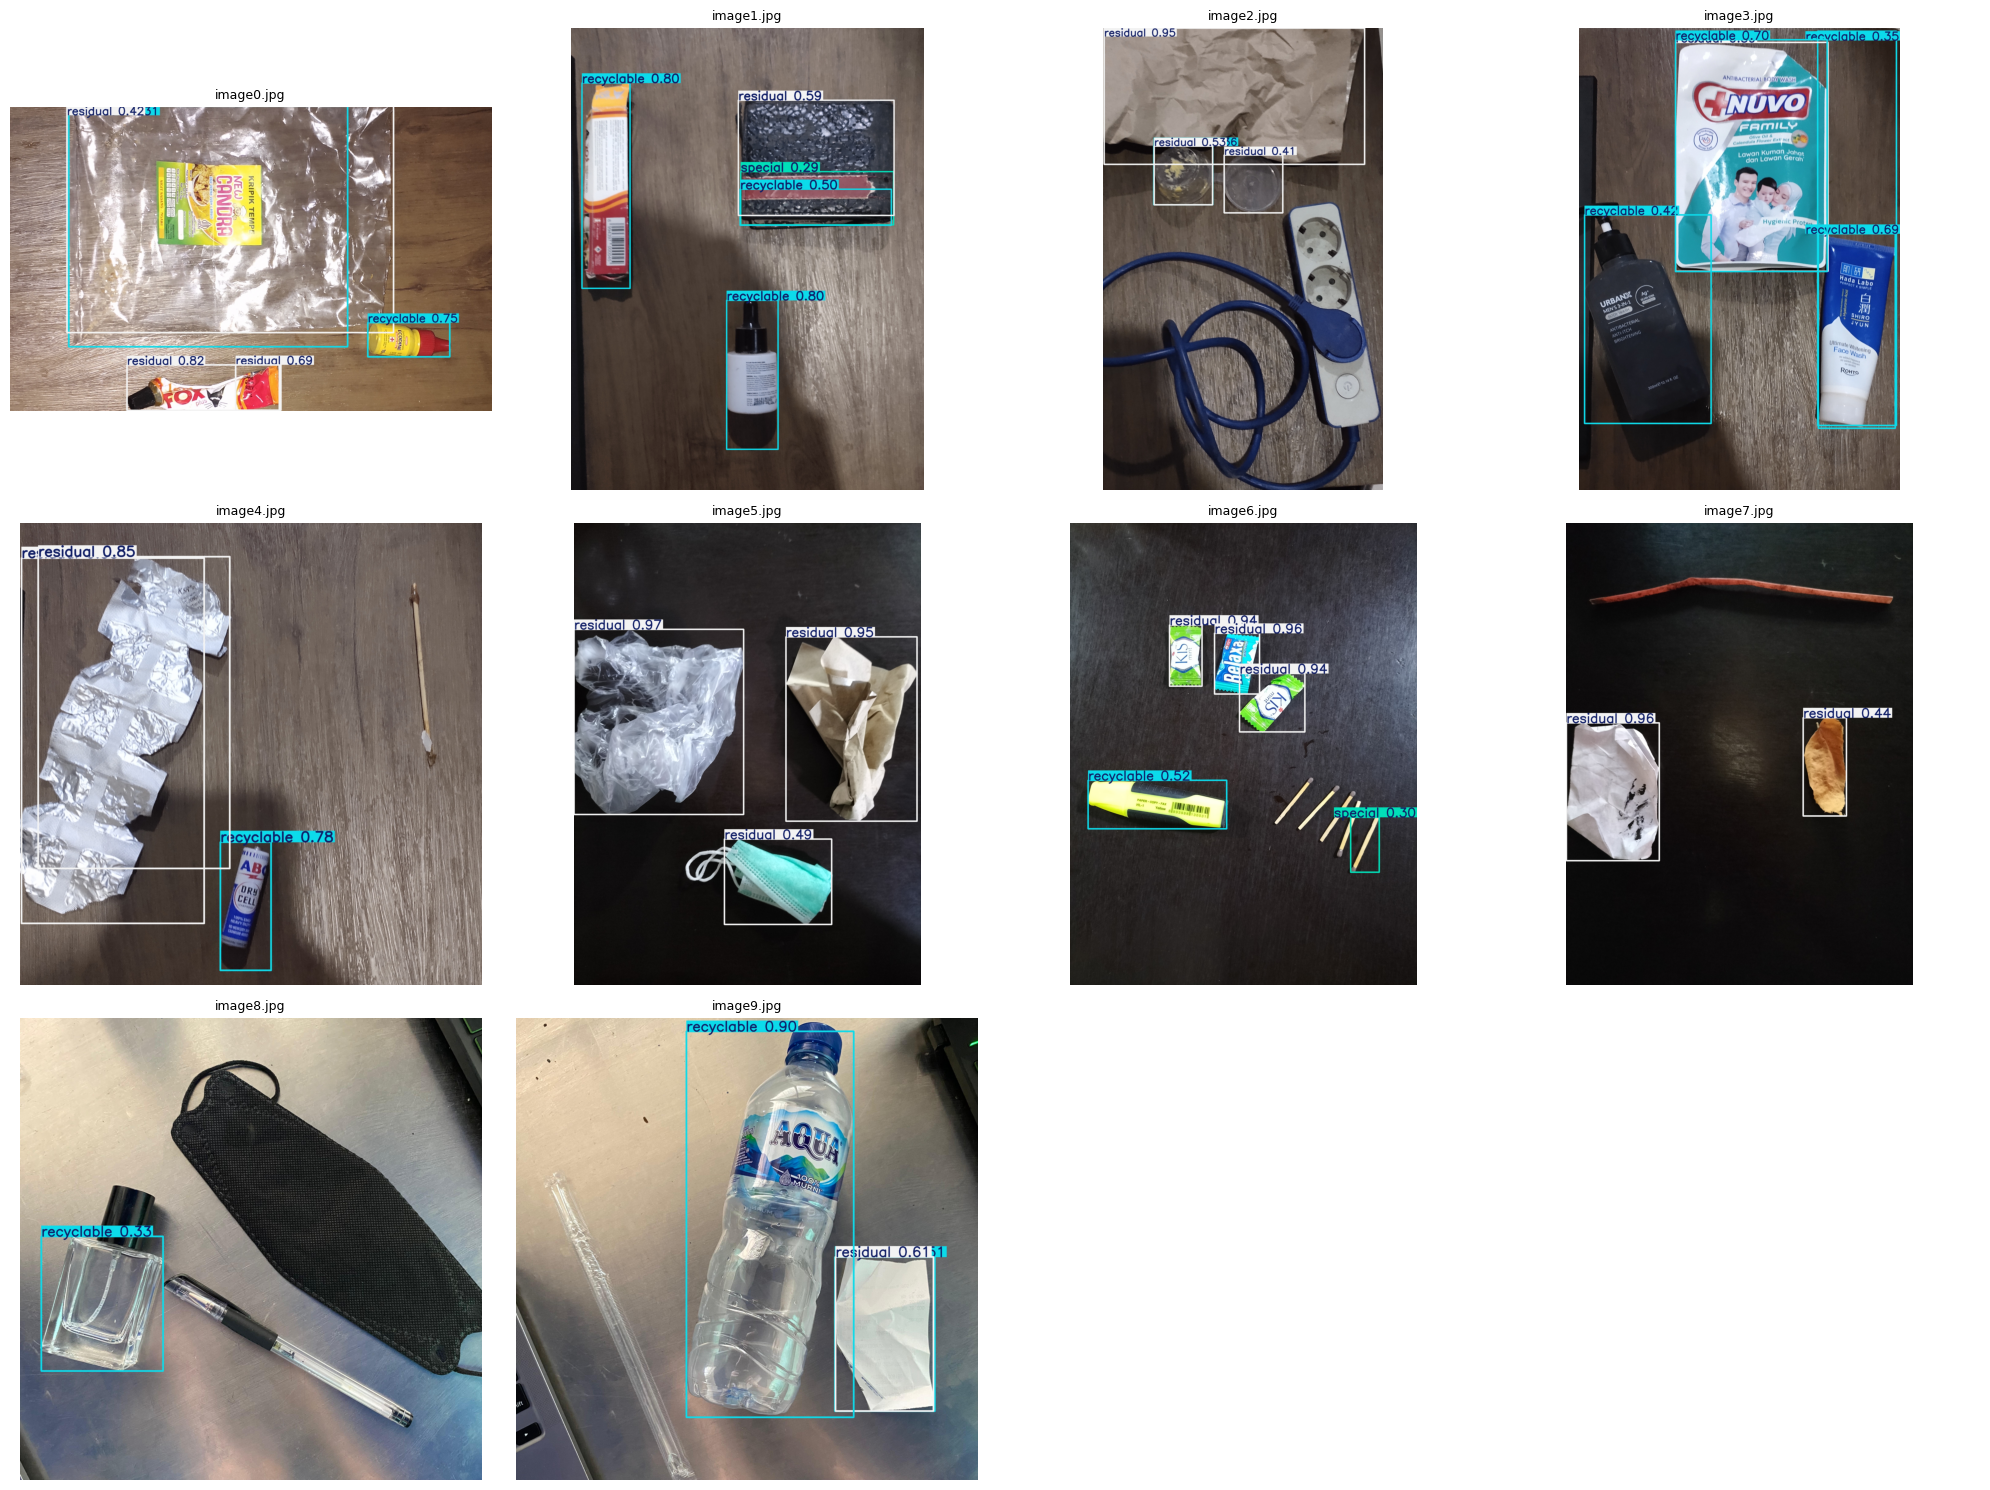

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

result_imgs = glob.glob(f"{PROJECT_DIR}/inference_results/personal_inference/*.jpg") + \
               glob.glob(f"{PROJECT_DIR}/inference_results/personal_inference/*.png")

n = len(result_imgs)
cols = min(4, n)
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
axes = axes.flatten() if n > 1 else [axes]

for i, img_path in enumerate(result_imgs):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(os.path.basename(img_path), fontsize=9)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# **10. Konversi Hasil Deteksi ke Tabular**

In [ ]:
import pandas as pd

personal_detection_records = []

for img_path, result in zip(image_paths, inference_results):
    filename = os.path.basename(img_path)

    labels = []
    if result.boxes is not None:
        for cls_id in result.boxes.cls:
            label_name = trained_model.names[int(cls_id)]
            labels.append(label_name)

    detected_labels_str = "|".join(sorted(set(labels))) if labels else "none"
    detected_count = len(set(labels))
    total_objects = len(labels)

    personal_detection_records.append({
        "image_filename": filename,
        "image_path": f"personal_images/{filename}",
        "detected_labels": detected_labels_str,
        "detected_count": detected_count,
        "total_objects": total_objects
    })

personal_df = pd.DataFrame(personal_detection_records)
print(personal_df)

  image_filename                image_path              detected_labels  \
0        003.jpg   personal_images/003.jpg          recyclable|residual   
1        004.jpg   personal_images/004.jpg  recyclable|residual|special   
2        007.jpg   personal_images/007.jpg          recyclable|residual   
3        006.jpg   personal_images/006.jpg          recyclable|residual   
4        005.jpg   personal_images/005.jpg          recyclable|residual   
5        009.jpg   personal_images/009.jpg                     residual   
6        008.jpg   personal_images/008.jpg  recyclable|residual|special   
7        010.jpg   personal_images/010.jpg                     residual   
8       001.jpeg  personal_images/001.jpeg                   recyclable   
9       002.jpeg  personal_images/002.jpeg          recyclable|residual   

   detected_count  total_objects  
0               2              5  
1               3              5  
2               2              4  
3               2              5  

# **11. Load Dataset Final & Mendeley (untuk distribusi temporal)**

In [ ]:
existing_df = pd.read_csv(f"{CSV_DIR}/dataset_final_waste_bekasi (1).csv")
mendeley = pd.read_csv(f"{CSV_DIR}/residential_waste_data.csv")

print("Existing dataset:", existing_df.shape)
print("Mendeley dataset:", mendeley.shape)
print(existing_df.head(2))

Existing dataset: (1000, 20)
Mendeley dataset: (8760, 3)
   record_id  user_id            timestamp        date  hour  day_of_week  \
0  REC-00058  USR-078  2025-01-01 08:50:44  2025-01-01     8            2   
1  REC-00258  USR-127  2025-01-01 10:39:43  2025-01-01    10            2   

   month     kecamatan     kelurahan    tps_code  \
0      1  Bekasi Barat       Bintara  TPS-BEK-02   
1      1  Bantargebang  Bantargebang  TPS-BAN-05   

                                     image_filename  \
0  623_jpeg.rf.af7c828917df2c72642089a298621142.jpg   
1  243_jpeg.rf.517292339f2ee0bfb1bbf8194b15a76f.jpg   

                                          image_path      detected_labels  \
0  train/images/623_jpeg.rf.af7c828917df2c7264208...             residual   
1  train/images/243_jpeg.rf.517292339f2ee0bfb1bbf...  recyclable|residual   

   detected_count  total_objects  weight_kg  is_weekend  is_peak_hour  \
0               1              5       3.45       False          True   
1         

# **12. Generate Metadata (Timestamp, Weight, Lokasi) untuk Foto Pribadi**

In [ ]:
import numpy as np

np.random.seed(123)

mendeley['Hour'] = pd.to_datetime(mendeley['Hour'])
mendeley['hour_of_day'] = mendeley['Hour'].dt.hour
hourly_stats = mendeley.groupby('hour_of_day')['Waste_kg'].agg(['mean', 'std']).fillna(0.005)
hour_probs = (hourly_stats['mean'] / hourly_stats['mean'].sum()).values

KECAMATAN_KELURAHAN = {
    "Bekasi Selatan": ["Margahayu", "Jakasampurna", "Pekayon Jaya", "Kayuringin Jaya"],
    "Bekasi Timur": ["Margahayu", "Bekasi Jaya", "Aren Jaya", "Duren Jaya"],
    "Bekasi Barat": ["Bintara", "Kranji", "Jakasampurna", "Kota Baru"],
    "Bekasi Utara": ["Perwira", "Harapan Jaya", "Kaliabang Tengah", "Teluk Pucung"],
    "Medan Satria": ["Medan Satria", "Pejuang", "Harapan Mulya", "Kalibaru"],
    "Pondok Gede": ["Jatibening", "Jaticempaka", "Jatiwaringin", "Jatiluhur"],
    "Pondok Melati": ["Jatimurni", "Jatirahayu", "Jatiwarna", "Jatimelati"],
    "Rawalumbu": ["Bojong Rawalumbu", "Sepanjang Jaya", "Pengasinan", "Bojong Menteng"],
    "Jatiasih": ["Jatiasih", "Jatikramat", "Jatirasa", "Jatimekar"],
    "Mustika Jaya": ["Mustika Jaya", "Mustikasari", "Padurenan", "Cimuning"],
    "Bantargebang": ["Bantargebang", "Sumur Batu", "Cikiwul", "Ciketingudik"],
    "Jatisampurna": ["Jatisampurna", "Jatiraden", "Jatirangga", "Jatikarya"],
}
KECAMATAN_LIST = list(KECAMATAN_KELURAHAN.keys())

next_record_num = existing_df['record_id'].str.replace("REC-", "").astype(int).max() + 1
existing_users = existing_df['user_id'].unique()

new_records = []
for i, row in personal_df.iterrows():
    record_id = f"REC-{next_record_num + i:05d}"
    user_id = np.random.choice(existing_users)

    sampled_hour = np.random.choice(24, p=hour_probs)
    sampled_date = pd.Timestamp("2025-01-01") + pd.Timedelta(days=int(np.random.randint(0, 365)))
    timestamp = sampled_date.replace(
        hour=int(sampled_hour),
        minute=int(np.random.randint(0, 60)),
        second=int(np.random.randint(0, 60))
    )

    mu = hourly_stats.loc[sampled_hour, 'mean']
    sigma = max(hourly_stats.loc[sampled_hour, 'std'], 0.005)
    weight = np.clip(np.random.normal(mu, sigma), 0.005, None)
    weight_kg = weight * np.random.uniform(15, 25)

    kecamatan = np.random.choice(KECAMATAN_LIST)
    kelurahan = np.random.choice(KECAMATAN_KELURAHAN[kecamatan])
    tps_code = f"TPS-{kecamatan[:3].upper()}-{np.random.randint(1,6):02d}"

    date_val = timestamp.date()
    hour_val = timestamp.hour
    dow = timestamp.dayofweek
    month_val = timestamp.month
    is_weekend = dow >= 5
    is_peak_hour = hour_val in [6,7,8,12,13,17,18,19,20]
    is_rainy_season = month_val in [11,12,1,2,3]
    seasonal_factor = round(np.random.uniform(1.05,1.20) if is_rainy_season else np.random.uniform(0.90,1.05), 3)
    weight_kg = round(weight_kg * seasonal_factor, 2)

    new_records.append({
        "record_id": record_id,
        "user_id": user_id,
        "timestamp": timestamp.strftime("%Y-%m-%d %H:%M:%S"),
        "date": str(date_val),
        "hour": hour_val,
        "day_of_week": dow,
        "month": month_val,
        "kecamatan": kecamatan,
        "kelurahan": kelurahan,
        "tps_code": tps_code,
        "image_filename": row['image_filename'],
        "image_path": row['image_path'],
        "detected_labels": row['detected_labels'],
        "detected_count": row['detected_count'],
        "total_objects": row['total_objects'],
        "weight_kg": weight_kg,
        "is_weekend": is_weekend,
        "is_peak_hour": is_peak_hour,
        "is_rainy_season": is_rainy_season,
        "seasonal_factor": seasonal_factor,
    })

new_df = pd.DataFrame(new_records)
print(new_df)

   record_id  user_id            timestamp        date  hour  day_of_week  \
0  REC-01001  USR-072  2025-04-09 10:38:17  2025-04-09    10            2   
1  REC-01002  USR-004  2025-12-01 11:36:32  2025-12-01    11            0   
2  REC-01003  USR-012  2025-02-17 18:56:48  2025-02-17    18            0   
3  REC-01004  USR-147  2025-04-17 17:05:00  2025-04-17    17            3   
4  REC-01005  USR-013  2025-06-08 20:52:06  2025-06-08    20            6   
5  REC-01006  USR-029  2025-12-24 13:55:25  2025-12-24    13            2   
6  REC-01007  USR-127  2025-08-22 10:48:56  2025-08-22    10            4   
7  REC-01008  USR-118  2025-08-11 17:06:09  2025-08-11    17            0   
8  REC-01009  USR-022  2025-11-27 15:35:52  2025-11-27    15            3   
9  REC-01010  USR-078  2025-11-21 20:30:07  2025-11-21    20            4   

   month       kecamatan     kelurahan    tps_code image_filename  \
0      4  Bekasi Selatan  Jakasampurna  TPS-BEK-02        003.jpg   
1     12    Be

# **13. Append ke Dataset Final & Simpan**

In [ ]:
final_combined_df = pd.concat([existing_df, new_df], ignore_index=True)
final_combined_df = final_combined_df.sort_values('timestamp').reset_index(drop=True)

output_path = f"{CSV_DIR}/dataset_final_waste_bekasi_v2.csv"
final_combined_df.to_csv(output_path, index=False)

print(f"Total records sekarang: {len(final_combined_df)}")
print(f"Saved to: {output_path}")
final_combined_df.tail(len(new_df))

Total records sekarang: 1010
Saved to: /content/drive/MyDrive/disposal_waste_final/csv/dataset_final_waste_bekasi_v2.csv


,record_id,user_id,timestamp,date,hour,day_of_week,month,kecamatan,kelurahan,tps_code,image_filename,image_path,detected_labels,detected_count,total_objects,weight_kg,is_weekend,is_peak_hour,is_rainy_season,seasonal_factor
1000,REC-00482,USR-166,2025-12-30 09:58:30,2025-12-30,9,1,12,Jatiasih,Jatikramat,TPS-JAT-04,695_jpeg.rf.b25046784df6552f71c9225a603090f6.jpg,train/images/695_jpeg.rf.b25046784df6552f71c92...,residual,1,4,2.74,False,False,True,1.103
1001,REC-00222,USR-182,2025-12-30 09:59:56,2025-12-30,9,1,12,Pondok Melati,Jatimelati,TPS-PON-05,335_jpeg.rf.1529bd06750ad154e355a7097baa5a41.jpg,train/images/335_jpeg.rf.1529bd06750ad154e355a...,recyclable|residual|special,3,15,2.60,False,False,True,1.060
1002,REC-00682,USR-029,2025-12-30 14:01:19,2025-12-30,14,1,12,Medan Satria,Pejuang,TPS-MED-03,718_jpeg.rf.cb24002b5f5ada17f441ec307680b68e.jpg,train/images/718_jpeg.rf.cb24002b5f5ada17f441e...,recyclable|residual,2,7,1.45,False,False,True,1.170
1003,REC-00804,USR-013,2025-12-31 08:25:21,2025-12-31,8,2,12,Mustika Jaya,Mustikasari,TPS-MUS-04,743_jpeg.rf.e7dd467ae0e47bb9eb7aaa21a3c8af29.jpg,train/images/743_jpeg.rf.e7dd467ae0e47bb9eb7aa...,recyclable|residual,2,3,3.15,False,True,True,1.135
1004,REC-00112,USR-012,2025-12-31 09:25:46,2025-12-31,9,2,12,Pondok Gede,Jatibening,TPS-PON-02,568_jpeg.rf.e1d4168f2934466c28e676a3f5f9b1a4.jpg,train/images/568_jpeg.rf.e1d4168f2934466c28e67...,biodegradable,1,1,2.00,False,False,True,1.135
1005,REC-00459,USR-195,2025-12-31 09:58:15,2025-12-31,9,2,12,Pondok Gede,Jatiwaringin,TPS-PON-04,606_jpeg.rf.fbc1be3029529927aa19da8fbef8a441.jpg,train/images/606_jpeg.rf.fbc1be3029529927aa19d...,residual,1,4,2.68,False,False,True,1.099
1006,REC-00467,USR-052,2025-12-31 13:21:42,2025-12-31,13,2,12,Bekasi Timur,Bekasi Jaya,TPS-BEK-03,540_jpeg.rf.0c57aca871b59ac6ba318cb4d4d2d3f0.jpg,train/images/540_jpeg.rf.0c57aca871b59ac6ba318...,residual,1,4,3.54,False,True,True,1.092
1007,REC-00068,USR-078,2025-12-31 13:25:13,2025-12-31,13,2,12,Bekasi Timur,Aren Jaya,TPS-BEK-03,675_jpeg.rf.8a308a5564768465d89e9a1b956fc410.jpg,train/images/675_jpeg.rf.8a308a5564768465d89e9...,recyclable|residual,2,2,2.53,False,True,True,1.130
1008,REC-00055,USR-030,2025-12-31 19:04:54,2025-12-31,19,2,12,Jatisampurna,Jatirangga,TPS-JAT-05,1035_jpeg.rf.21970738c4b05b78b25118f11e735fbe.jpg,train/images/1035_jpeg.rf.21970738c4b05b78b251...,recyclable|residual,2,2,5.27,False,True,True,1.162
1009,REC-00626,USR-080,2025-12-31 19:53:36,2025-12-31,19,2,12,Pondok Gede,Jatiluhur,TPS-PON-05,882_jpeg.rf.4901dc7770d193e8c17526c902e9bdf1.jpg,train/images/882_jpeg.rf.4901dc7770d193e8c1752...,residual,1,2,3.75,False,True,True,1.053


# **14. Load Dataset Final & Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

# Re-define PROJECT_DIR and CSV_DIR for robustness if this cell is run independently
# or if kernel state is lost.
PROJECT_DIR = "/content/drive/MyDrive/disposal_waste_final"
CSV_DIR = f"{PROJECT_DIR}/csv"

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

file_path = f"{CSV_DIR}/dataset_final_waste_bekasi_v2.csv"

# Diagnostic: Check contents of CSV_DIR immediately before reading
print(f"Contents of {CSV_DIR}: {os.listdir(CSV_DIR)}")

# Robust file loading with retry for Drive synchronization issues
max_retries = 5
retry_delay_seconds = 2

df = None
for i in range(max_retries):
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            print(f"Successfully loaded {file_path}.")
            break
        except Exception as e:
            print(f"Attempt {i+1}/{max_retries}: Error reading file {file_path}: {e}")
    else:
        print(f"Attempt {i+1}/{max_retries}: File not found at {file_path}.")

    if i < max_retries - 1:
        print(f"Retrying in {retry_delay_seconds} seconds...")
        time.sleep(retry_delay_seconds)

if df is None:
    raise FileNotFoundError(f"Failed to load {file_path} after {max_retries} attempts.")

df['timestamp'] = pd.to_datetime(df['timestamp'])

print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistik deskriptif:")
print(df.describe())

Contents of /content/drive/MyDrive/disposal_waste_final/csv: ['dataset_final_waste_bekasi (1).csv', 'residential_waste_data.csv', 'dataset_final_waste_bekasi_v2.csv']
Successfully loaded /content/drive/MyDrive/disposal_waste_final/csv/dataset_final_waste_bekasi_v2.csv.
Shape: (1010, 20)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   record_id        1010 non-null   object        
 1   user_id          1010 non-null   object        
 2   timestamp        1010 non-null   datetime64[ns]
 3   date             1010 non-null   object        
 4   hour             1010 non-null   int64         
 5   day_of_week      1010 non-null   int64         
 6   month            1010 non-null   int64         
 7   kecamatan        1010 non-null   object        
 8   kelurahan        1010 non-null   object        
 9   tps_code  

# **15. Distribusi Jenis Sampah & Berat**

/tmp/ipykernel_1267/855621847.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, ax=axes[0], palette="viridis")


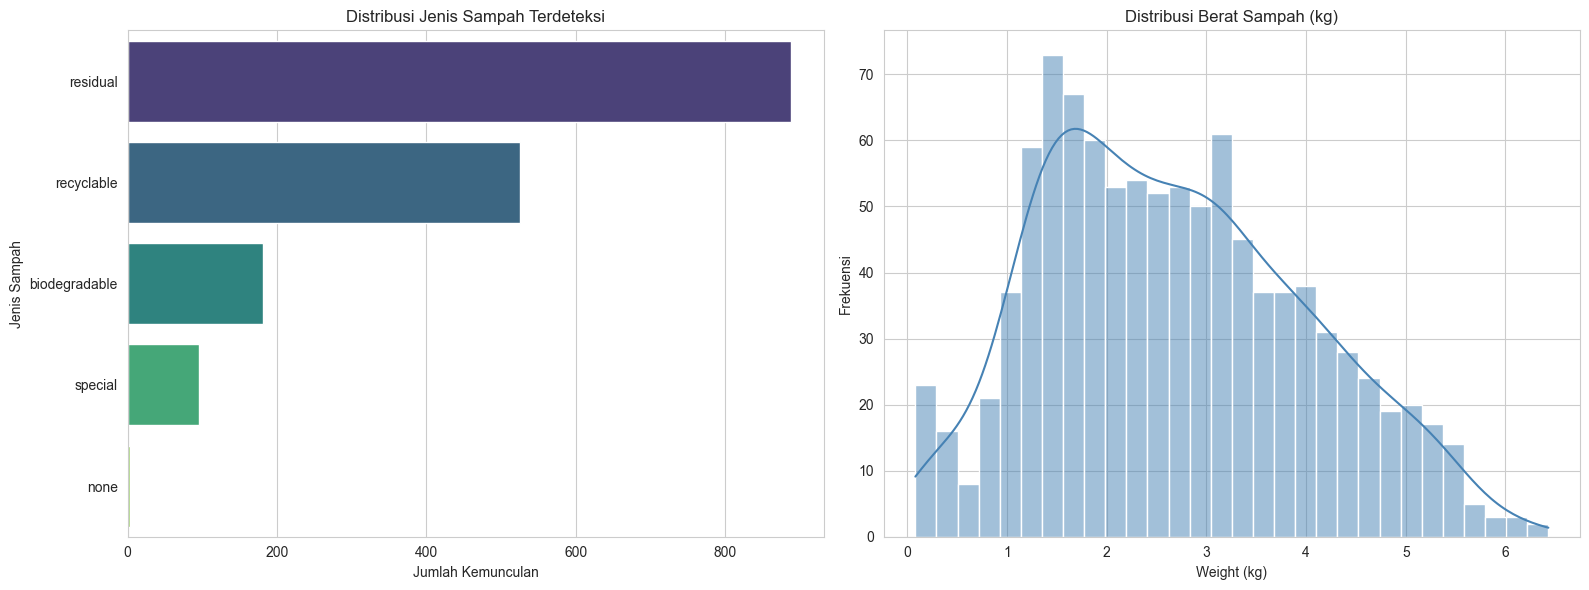

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribusi jenis sampah (split detected_labels yang multi-label)
all_labels = df['detected_labels'].str.split('|').explode()
label_counts = all_labels.value_counts()

sns.barplot(x=label_counts.values, y=label_counts.index, ax=axes[0], palette="viridis")
axes[0].set_title("Distribusi Jenis Sampah Terdeteksi")
axes[0].set_xlabel("Jumlah Kemunculan")
axes[0].set_ylabel("Jenis Sampah")

# Distribusi berat sampah
sns.histplot(df['weight_kg'], bins=30, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Distribusi Berat Sampah (kg)")
axes[1].set_xlabel("Weight (kg)")
axes[1].set_ylabel("Frekuensi")

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/eda_distribusi_jenis_berat.png", dpi=100)
plt.show()

# **16. Distribusi Jam, Hari, Bulan Pembuangan**

/tmp/ipykernel_1267/565963268.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=axes[0], palette="rocket")
/tmp/ipykernel_1267/565963268.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[day_names[i] for i in dow_counts.index], y=dow_counts.values, ax=axes[1], palette="mako")
/tmp/ipykernel_1267/565963268.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[2], palette="flare")


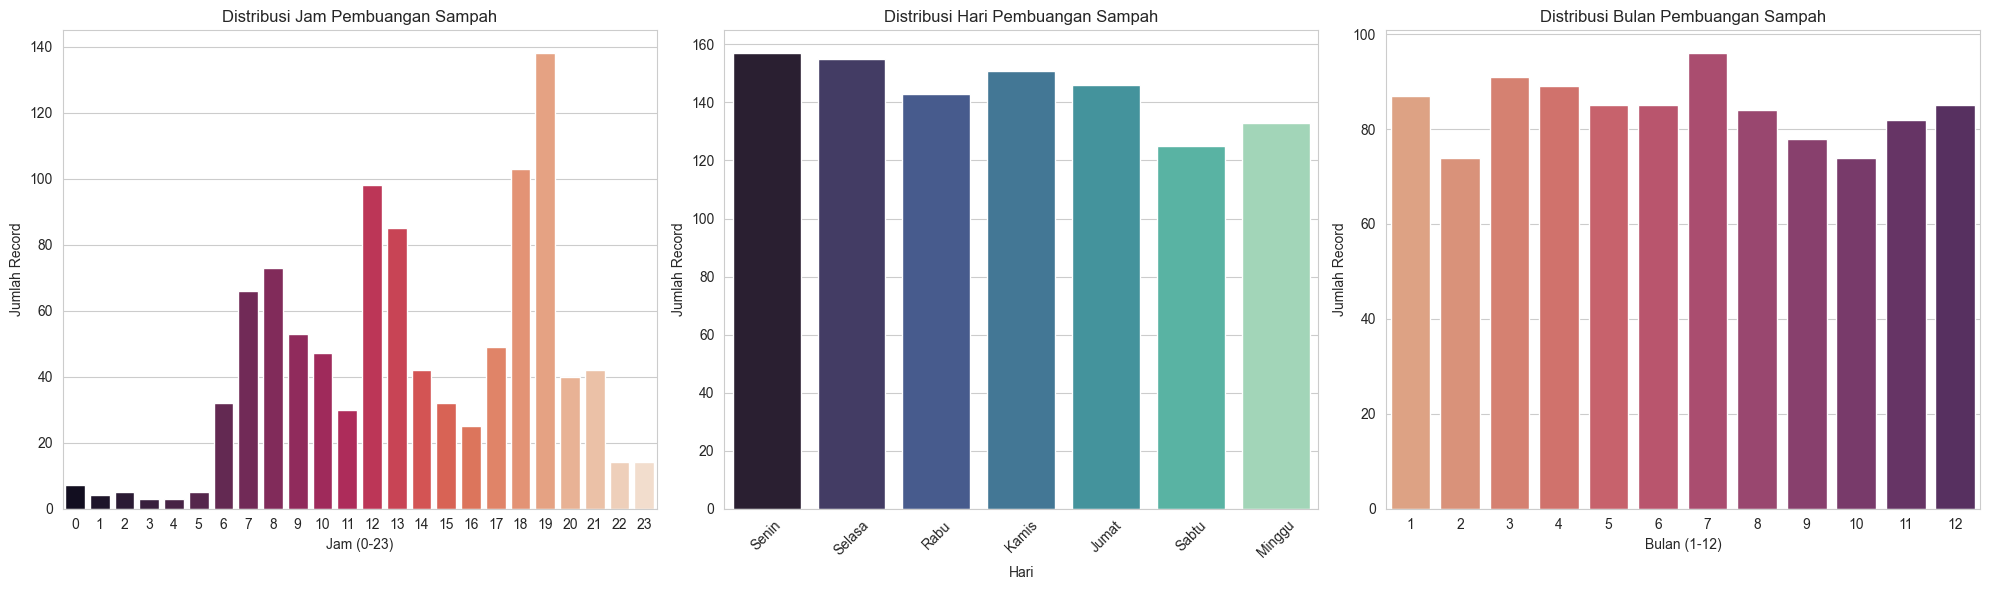

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Distribusi jam
hour_counts = df['hour'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values, ax=axes[0], palette="rocket")
axes[0].set_title("Distribusi Jam Pembuangan Sampah")
axes[0].set_xlabel("Jam (0-23)")
axes[0].set_ylabel("Jumlah Record")

# Distribusi hari (0=Senin, 6=Minggu)
day_names = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
dow_counts = df['day_of_week'].value_counts().sort_index()
sns.barplot(x=[day_names[i] for i in dow_counts.index], y=dow_counts.values, ax=axes[1], palette="mako")
axes[1].set_title("Distribusi Hari Pembuangan Sampah")
axes[1].set_xlabel("Hari")
axes[1].set_ylabel("Jumlah Record")
axes[1].tick_params(axis='x', rotation=45)

# Distribusi bulan
month_counts = df['month'].value_counts().sort_index()
sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[2], palette="flare")
axes[2].set_title("Distribusi Bulan Pembuangan Sampah")
axes[2].set_xlabel("Bulan (1-12)")
axes[2].set_ylabel("Jumlah Record")

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/eda_distribusi_waktu.png", dpi=100)
plt.show()

# **17. Heatmap Waktu & Peak Disposal Time**

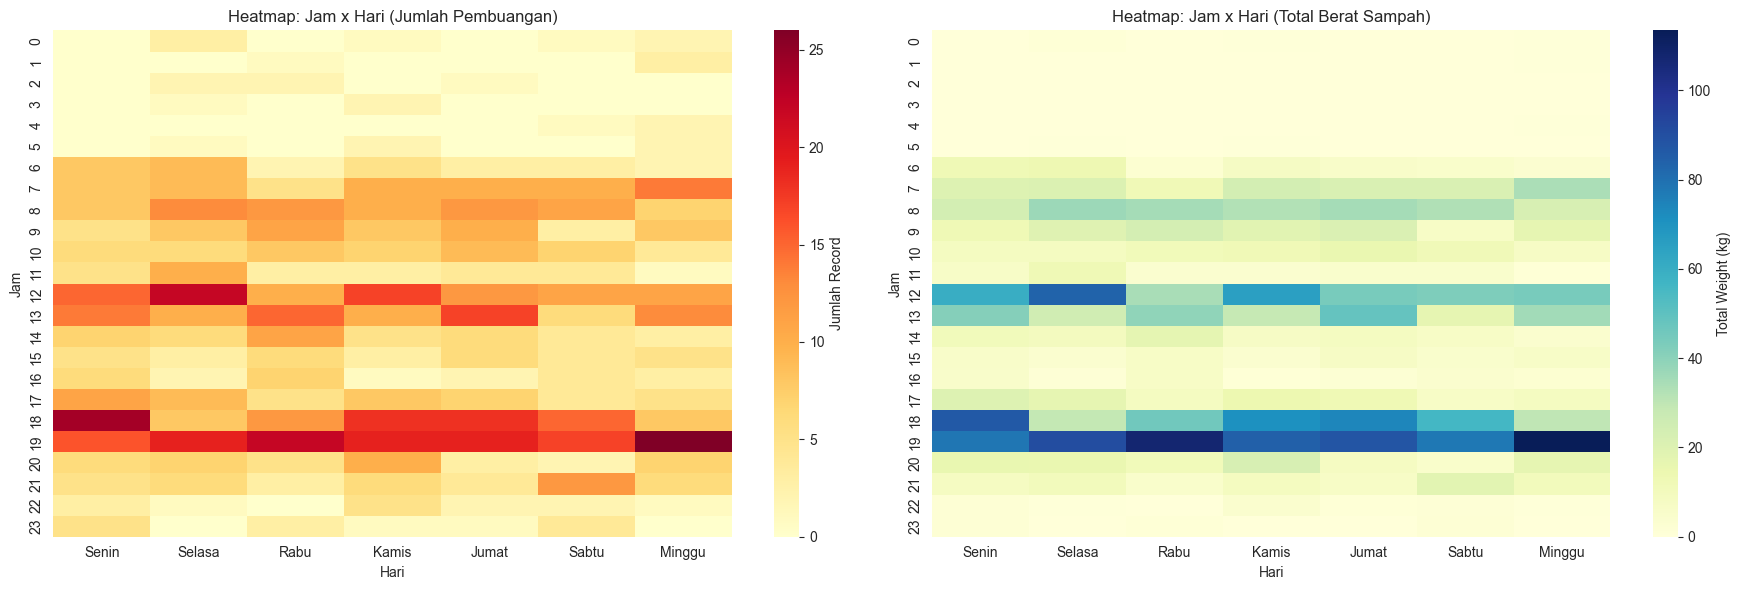

=== PEAK DISPOSAL TIME ===

Top 5 jam dengan record terbanyak:
hour
19    138
18    103
12     98
13     85
8      73
Name: count, dtype: int64

Top 5 kombinasi (jam, hari) dengan total berat tertinggi:
  Jam 19:00, Minggu -> 113.39 kg
  Jam 19:00, Rabu -> 107.48 kg
  Jam 19:00, Selasa -> 90.46 kg
  Jam 19:00, Jumat -> 88.11 kg
  Jam 18:00, Senin -> 86.68 kg


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap: hour vs day_of_week (berdasarkan jumlah record)
pivot_count = df.pivot_table(index='hour', columns='day_of_week', values='record_id', aggfunc='count', fill_value=0)
pivot_count.columns = [day_names[i] for i in pivot_count.columns]
sns.heatmap(pivot_count, cmap="YlOrRd", annot=False, ax=axes[0], cbar_kws={'label': 'Jumlah Record'})
axes[0].set_title("Heatmap: Jam x Hari (Jumlah Pembuangan)")
axes[0].set_xlabel("Hari")
axes[0].set_ylabel("Jam")

# Heatmap: hour vs day_of_week (berdasarkan total berat)
pivot_weight = df.pivot_table(index='hour', columns='day_of_week', values='weight_kg', aggfunc='sum', fill_value=0)
pivot_weight.columns = [day_names[i] for i in pivot_weight.columns]
sns.heatmap(pivot_weight, cmap="YlGnBu", annot=False, ax=axes[1], cbar_kws={'label': 'Total Weight (kg)'})
axes[1].set_title("Heatmap: Jam x Hari (Total Berat Sampah)")
axes[1].set_xlabel("Hari")
axes[1].set_ylabel("Jam")

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/eda_heatmap_waktu.png", dpi=100)
plt.show()

# Identifikasi Peak Disposal Time
print("=== PEAK DISPOSAL TIME ===")
print("\nTop 5 jam dengan record terbanyak:")
print(hour_counts.sort_values(ascending=False).head(5))

print("\nTop 5 kombinasi (jam, hari) dengan total berat tertinggi:")
combo = df.groupby(['hour','day_of_week'])['weight_kg'].sum().sort_values(ascending=False).head(5)
for (h, d), w in combo.items():
    print(f"  Jam {h}:00, {day_names[d]} -> {w:.2f} kg")

# **18. Distribusi Kecamatan & TPS**

/tmp/ipykernel_1267/343871740.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kec_counts.values, y=kec_counts.index, ax=axes[0], palette="cubehelix")
/tmp/ipykernel_1267/343871740.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kec_weight.values, y=kec_weight.index, ax=axes[1], palette="crest")


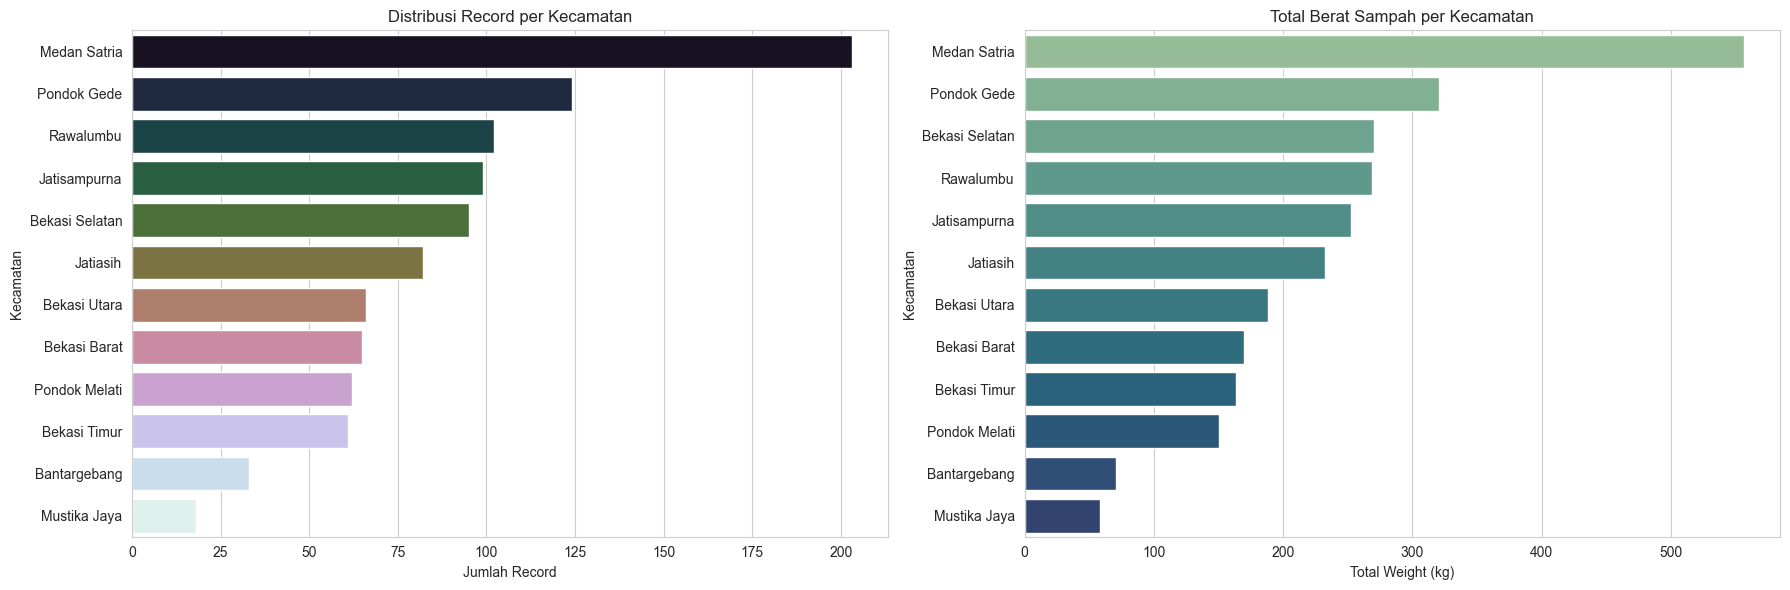

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Distribusi kecamatan
kec_counts = df['kecamatan'].value_counts()
sns.barplot(x=kec_counts.values, y=kec_counts.index, ax=axes[0], palette="cubehelix")
axes[0].set_title("Distribusi Record per Kecamatan")
axes[0].set_xlabel("Jumlah Record")
axes[0].set_ylabel("Kecamatan")

# Total berat sampah per kecamatan
kec_weight = df.groupby('kecamatan')['weight_kg'].sum().sort_values(ascending=False)
sns.barplot(x=kec_weight.values, y=kec_weight.index, ax=axes[1], palette="crest")
axes[1].set_title("Total Berat Sampah per Kecamatan")
axes[1].set_xlabel("Total Weight (kg)")
axes[1].set_ylabel("Kecamatan")

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/eda_distribusi_kecamatan.png", dpi=100)
plt.show()

# **19. Korelasi Fitur & Analisis Tambahan**

/tmp/ipykernel_1267/3465551378.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_weekend', y='weight_kg', data=df, ax=axes[0,1], palette="Set2")
/tmp/ipykernel_1267/3465551378.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(['Weekday', 'Weekend'])
/tmp/ipykernel_1267/3465551378.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_rainy_season', y='weight_kg', data=df, ax=axes[1,0], palette="Set3")
/tmp/ipykernel_1267/3465551378.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

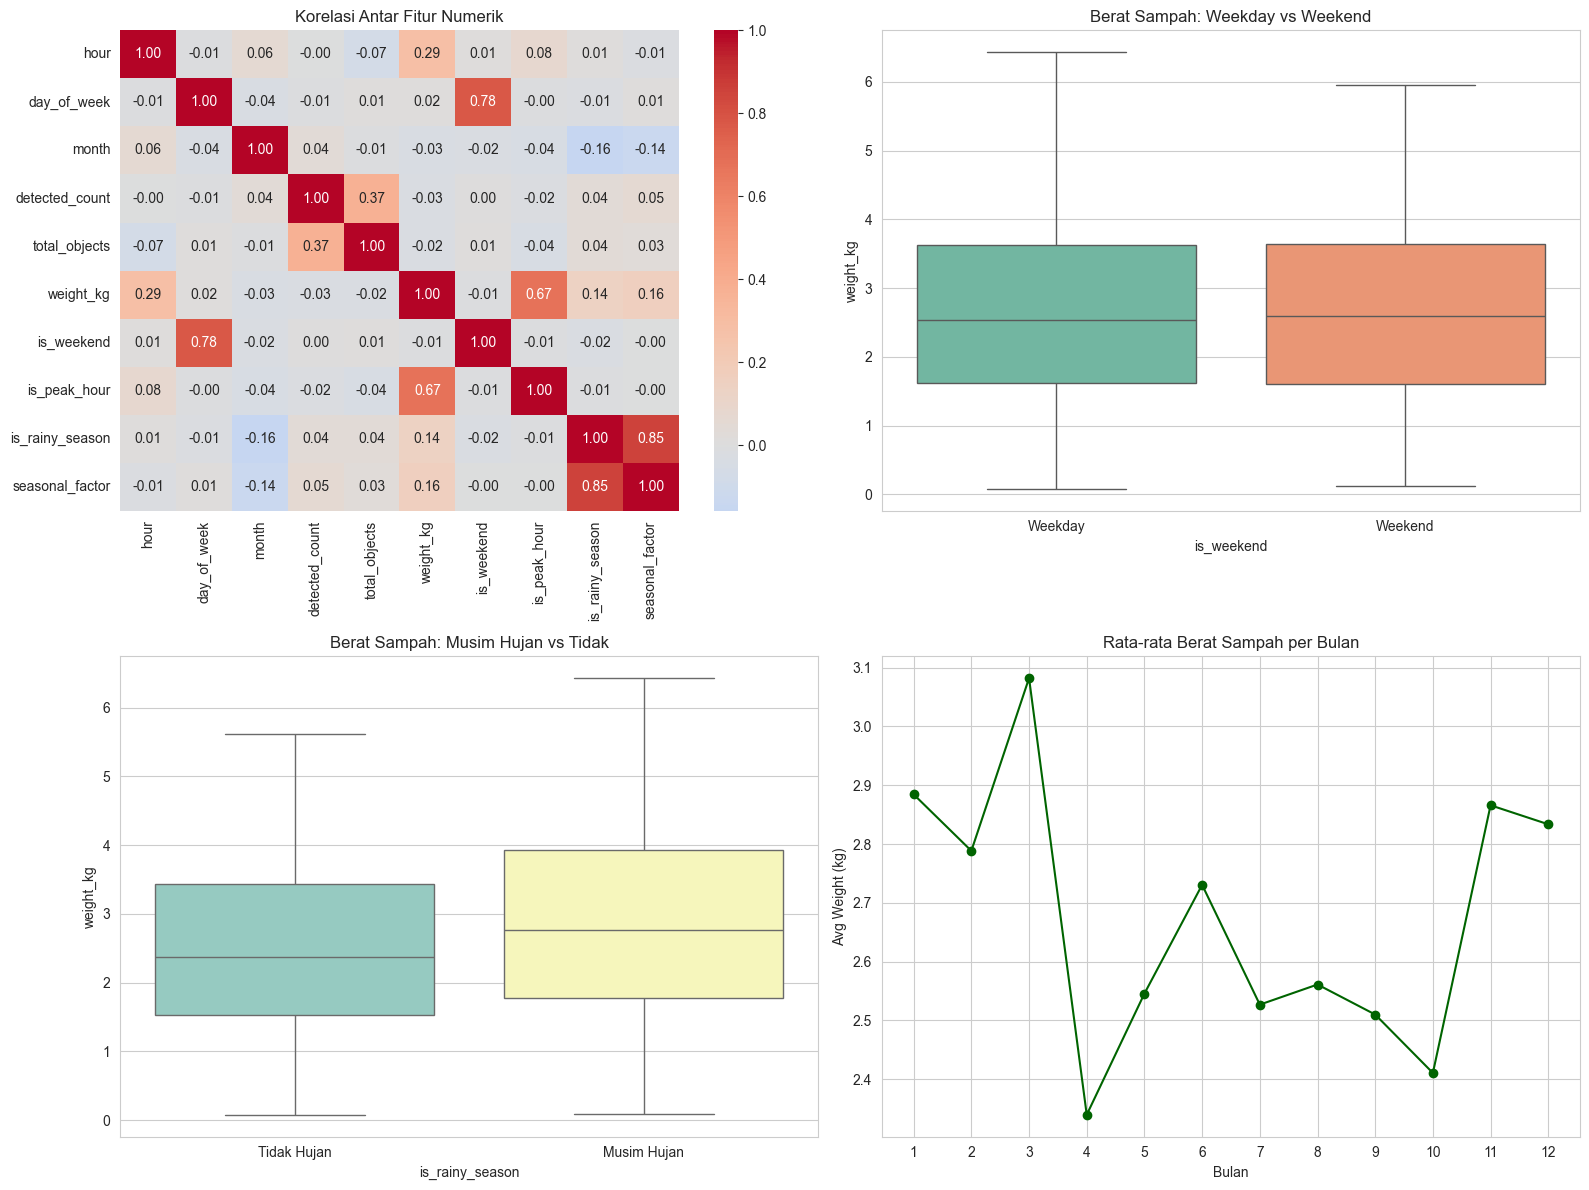


=== RINGKASAN EDA ===
Total records: 1010
Rentang waktu: 2025-01-01 08:50:44 - 2025-12-31 19:53:36
Total berat sampah: 2702.24 kg
Rata-rata berat per record: 2.68 kg

Proporsi is_peak_hour: 67.7%
Proporsi is_weekend: 25.5%
Proporsi is_rainy_season: 41.5%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Korelasi numerik
numeric_cols = ['hour', 'day_of_week', 'month', 'detected_count', 'total_objects',
                 'weight_kg', 'is_weekend', 'is_peak_hour', 'is_rainy_season', 'seasonal_factor']
corr = df[numeric_cols].astype(float).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0,0])
axes[0,0].set_title("Korelasi Antar Fitur Numerik")

# 2. Weekend vs Weekday - berat sampah
sns.boxplot(x='is_weekend', y='weight_kg', data=df, ax=axes[0,1], palette="Set2")
axes[0,1].set_title("Berat Sampah: Weekday vs Weekend")
axes[0,1].set_xticklabels(['Weekday', 'Weekend'])

# 3. Musim hujan vs tidak - berat sampah
sns.boxplot(x='is_rainy_season', y='weight_kg', data=df, ax=axes[1,0], palette="Set3")
axes[1,0].set_title("Berat Sampah: Musim Hujan vs Tidak")
axes[1,0].set_xticklabels(['Tidak Hujan', 'Musim Hujan'])

# 4. Trend bulanan rata-rata berat
monthly_avg = df.groupby('month')['weight_kg'].mean()
axes[1,1].plot(monthly_avg.index, monthly_avg.values, marker='o', color='darkgreen')
axes[1,1].set_title("Rata-rata Berat Sampah per Bulan")
axes[1,1].set_xlabel("Bulan")
axes[1,1].set_ylabel("Avg Weight (kg)")
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/eda_korelasi_analisis.png", dpi=100)
plt.show()

print("\n=== RINGKASAN EDA ===")
print(f"Total records: {len(df)}")
print(f"Rentang waktu: {df['timestamp'].min()} - {df['timestamp'].max()}")
print(f"Total berat sampah: {df['weight_kg'].sum():.2f} kg")
print(f"Rata-rata berat per record: {df['weight_kg'].mean():.2f} kg")
print(f"\nProporsi is_peak_hour: {df['is_peak_hour'].mean()*100:.1f}%")
print(f"Proporsi is_weekend: {df['is_weekend'].mean()*100:.1f}%")
print(f"Proporsi is_rainy_season: {df['is_rainy_season'].mean()*100:.1f}%")

# **20. Peak Disposal Time Deep Analysis**

PEAK DISPOSAL TIME ANALYSIS
Threshold (mean + 1 std): 78.4 records/jam

Peak Hours Teridentifikasi: [12, 13, 18, 19]

Detail per jam peak:
 hour  count  total_weight  avg_weight
   12     98        373.95    3.815816
   13     85        235.14    2.766353
   18    103        392.29    3.808641
   19    138        639.53    4.634275


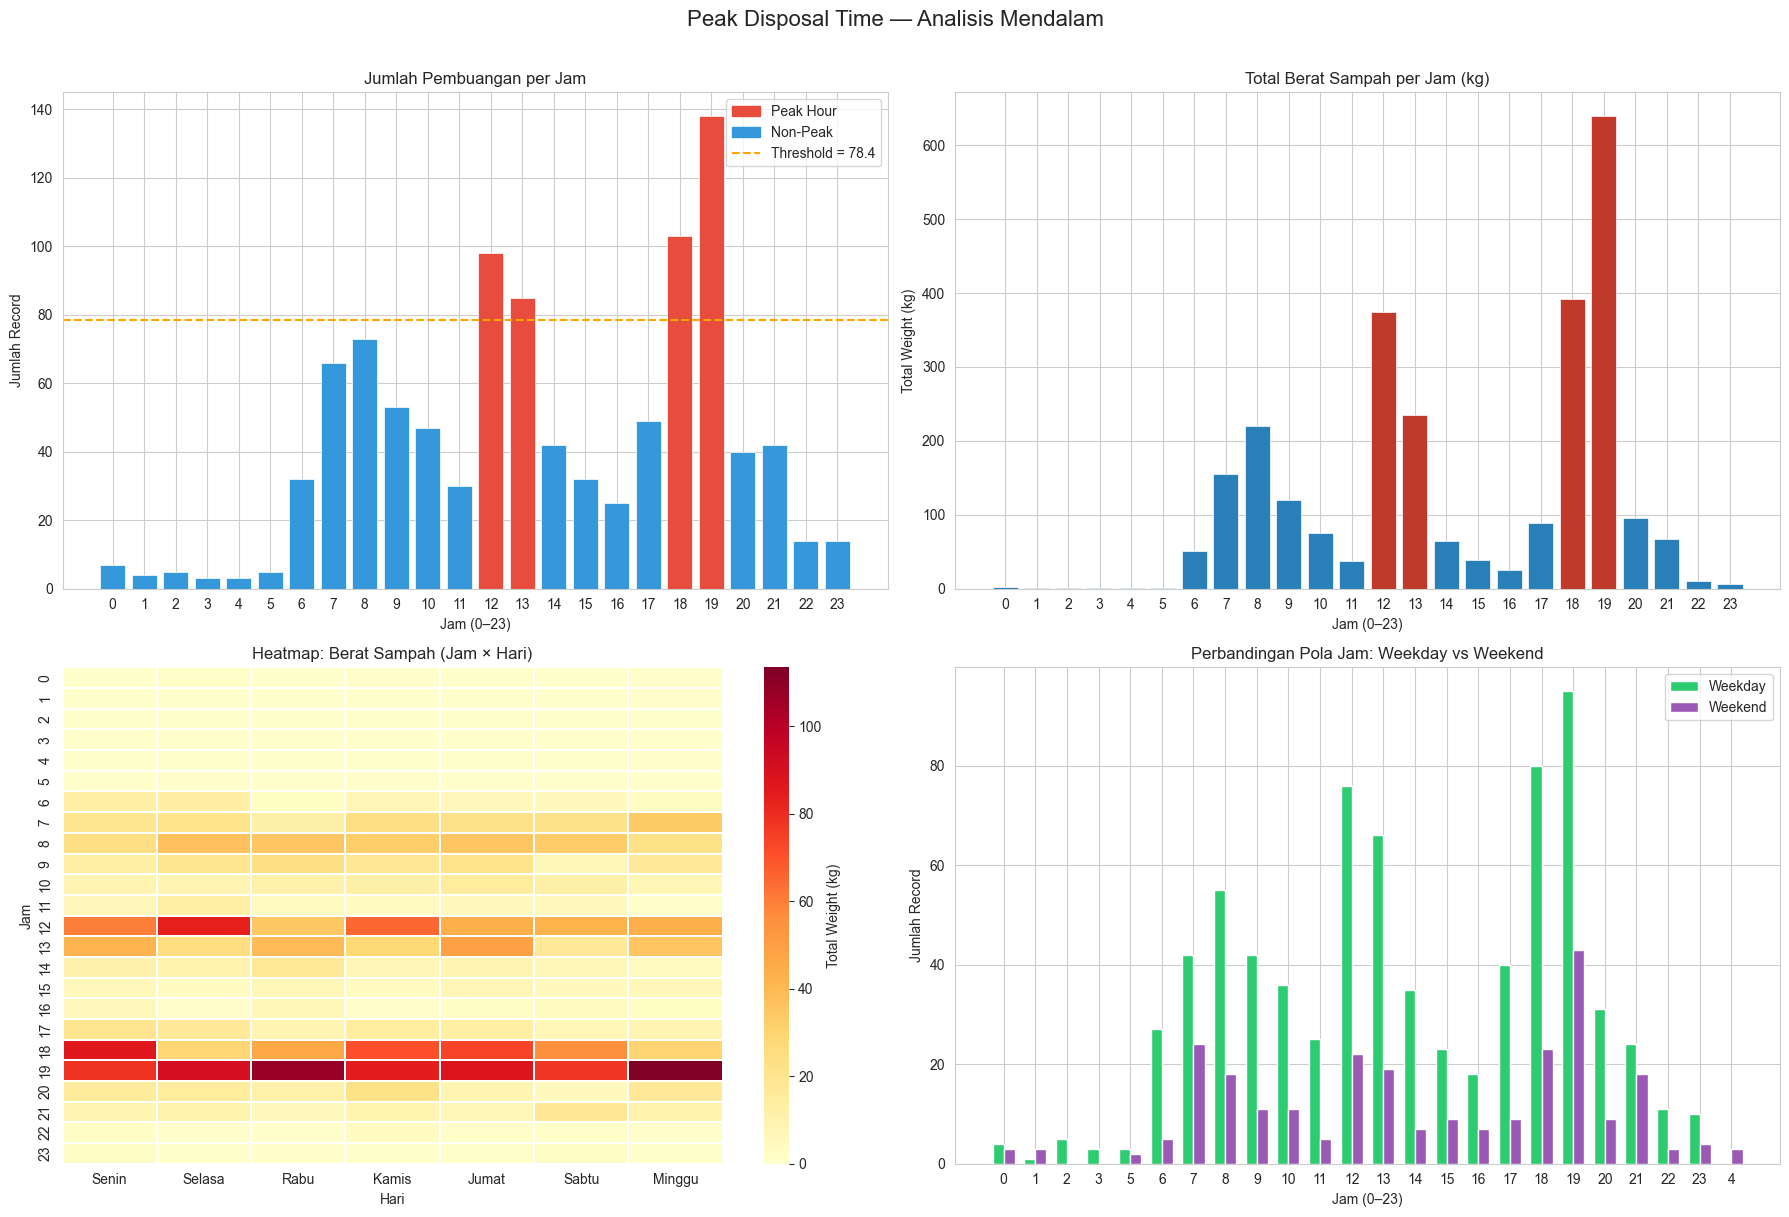


Top 10 kombinasi Jam × Hari berdasarkan total berat:
  Jam 19:00, Minggu → 113.39 kg
  Jam 19:00,   Rabu → 107.48 kg
  Jam 19:00, Selasa → 90.46 kg
  Jam 19:00,  Jumat → 88.11 kg
  Jam 18:00,  Senin → 86.68 kg
  Jam 19:00,  Kamis → 84.50 kg
  Jam 12:00, Selasa → 83.43 kg
  Jam 19:00,  Senin → 78.02 kg
  Jam 19:00,  Sabtu → 77.57 kg
  Jam 18:00,  Jumat → 73.80 kg

✅ PEAK_HOURS_IDENTIFIED = [12, 13, 18, 19]
   (variabel ini akan dipakai di cell-cell selanjutnya)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Pastikan df sudah ter-load dan timestamp sudah datetime
# Jalankan Cell 13 terlebih dahulu jika belum

PROJECT_DIR = "/content/drive/MyDrive/disposal_waste_final"
CSV_DIR = f"{PROJECT_DIR}/csv"

# Jika df belum ada di memory, load ulang
try:
    df
except NameError:
    df = pd.read_csv(f"{CSV_DIR}/dataset_final_waste_bekasi_v2.csv")
    df['timestamp'] = pd.to_datetime(df['timestamp'])

DAY_MAP = {0:'Senin',1:'Selasa',2:'Rabu',3:'Kamis',4:'Jumat',5:'Sabtu',6:'Minggu'}
df['day_name'] = df['day_of_week'].map(DAY_MAP)

# ── 1. Statistik per jam ──────────────────────────────────────────────────────
hourly = df.groupby('hour').agg(
    count=('record_id','count'),
    total_weight=('weight_kg','sum'),
    avg_weight=('weight_kg','mean')
).reset_index()

threshold_count = hourly['count'].mean() + hourly['count'].std()
hourly['is_peak'] = hourly['count'] >= threshold_count

peak_hours = hourly[hourly['is_peak']]['hour'].tolist()
print("=" * 55)
print("PEAK DISPOSAL TIME ANALYSIS")
print("=" * 55)
print(f"Threshold (mean + 1 std): {threshold_count:.1f} records/jam")
print(f"\nPeak Hours Teridentifikasi: {peak_hours}")
print(f"\nDetail per jam peak:")
print(hourly[hourly['is_peak']][['hour','count','total_weight','avg_weight']].to_string(index=False))

# ── 2. Visualisasi bar chart peak hour ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Peak Disposal Time — Analisis Mendalam', fontsize=16, fontweight='bold', y=1.01)

# Panel A: Count per jam
colors_a = ['#E74C3C' if p else '#3498DB' for p in hourly['is_peak']]
axes[0,0].bar(hourly['hour'], hourly['count'], color=colors_a, edgecolor='white', linewidth=0.5)
axes[0,0].axhline(threshold_count, color='orange', linestyle='--', linewidth=1.5, label=f'Threshold = {threshold_count:.1f}')
axes[0,0].set_title('Jumlah Pembuangan per Jam', fontweight='bold')
axes[0,0].set_xlabel('Jam (0–23)')
axes[0,0].set_ylabel('Jumlah Record')
axes[0,0].set_xticks(range(24))
axes[0,0].legend()
peak_patch = mpatches.Patch(color='#E74C3C', label='Peak Hour')
norm_patch = mpatches.Patch(color='#3498DB', label='Non-Peak')
axes[0,0].legend(handles=[peak_patch, norm_patch, axes[0,0].get_lines()[0]])

# Panel B: Total berat per jam
colors_b = ['#C0392B' if p else '#2980B9' for p in hourly['is_peak']]
axes[0,1].bar(hourly['hour'], hourly['total_weight'], color=colors_b, edgecolor='white', linewidth=0.5)
axes[0,1].set_title('Total Berat Sampah per Jam (kg)', fontweight='bold')
axes[0,1].set_xlabel('Jam (0–23)')
axes[0,1].set_ylabel('Total Weight (kg)')
axes[0,1].set_xticks(range(24))

# Panel C: Heatmap Hour × Day
pivot_hd = df.groupby(['hour','day_name'])['weight_kg'].sum().unstack(fill_value=0)
day_order = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
pivot_hd = pivot_hd.reindex(columns=[d for d in day_order if d in pivot_hd.columns])
sns.heatmap(pivot_hd, ax=axes[1,0], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label':'Total Weight (kg)'})
axes[1,0].set_title('Heatmap: Berat Sampah (Jam × Hari)', fontweight='bold')
axes[1,0].set_xlabel('Hari')
axes[1,0].set_ylabel('Jam')

# Panel D: Weekday vs Weekend per jam
wk = df[~df['is_weekend']].groupby('hour')['record_id'].count().rename('Weekday')
we = df[df['is_weekend']].groupby('hour')['record_id'].count().rename('Weekend')
comp = pd.concat([wk, we], axis=1).fillna(0)
x = np.arange(len(comp))
w = 0.35
axes[1,1].bar(x - w/2, comp['Weekday'], w, label='Weekday', color='#2ECC71')
axes[1,1].bar(x + w/2, comp['Weekend'], w, label='Weekend', color='#9B59B6')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(comp.index)
axes[1,1].set_title('Perbandingan Pola Jam: Weekday vs Weekend', fontweight='bold')
axes[1,1].set_xlabel('Jam (0–23)')
axes[1,1].set_ylabel('Jumlah Record')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/analysis_peak_disposal_time.png", dpi=120, bbox_inches='tight')
plt.show()

# ── 3. Top kombinasi (jam × hari) ─────────────────────────────────────────────
print("\nTop 10 kombinasi Jam × Hari berdasarkan total berat:")
combo = df.groupby(['hour','day_name'])['weight_kg'].sum().reset_index()
combo = combo.sort_values('weight_kg', ascending=False).head(10)
for _, r in combo.iterrows():
    print(f"  Jam {int(r['hour']):02d}:00, {r['day_name']:>6s} → {r['weight_kg']:.2f} kg")

# ── 4. Simpan ringkasan peak hours ke variabel global ─────────────────────────
PEAK_HOURS_IDENTIFIED = peak_hours
print(f"\n✅ PEAK_HOURS_IDENTIFIED = {PEAK_HOURS_IDENTIFIED}")
print("   (variabel ini akan dipakai di cell-cell selanjutnya)")

# **21. User Behavior Pattern Analysis**

USER BEHAVIOR PATTERN SUMMARY
Total unique users: 198

Statistik disposal per user:
       total_disposal  total_weight  avg_weight  peak_hour_ratio  \
count          198.00        198.00      198.00           198.00   
mean             5.10         13.65        2.67             0.68   
std              2.13          6.57        0.66             0.24   
min              1.00          1.94        0.97             0.00   
25%              4.00          8.85        2.25             0.50   
50%              5.00         12.75        2.67             0.71   
75%              6.00         18.58        3.06             0.83   
max             11.00         34.05        4.90             1.00   

       weekend_ratio  
count         198.00  
mean            0.27  
std             0.23  
min             0.00  
25%             0.12  
50%             0.25  
75%             0.40  
max             1.00  

Distribusi Behavior Category (Pre-Clustering):
behavior_category
Occasional          56
Weekend

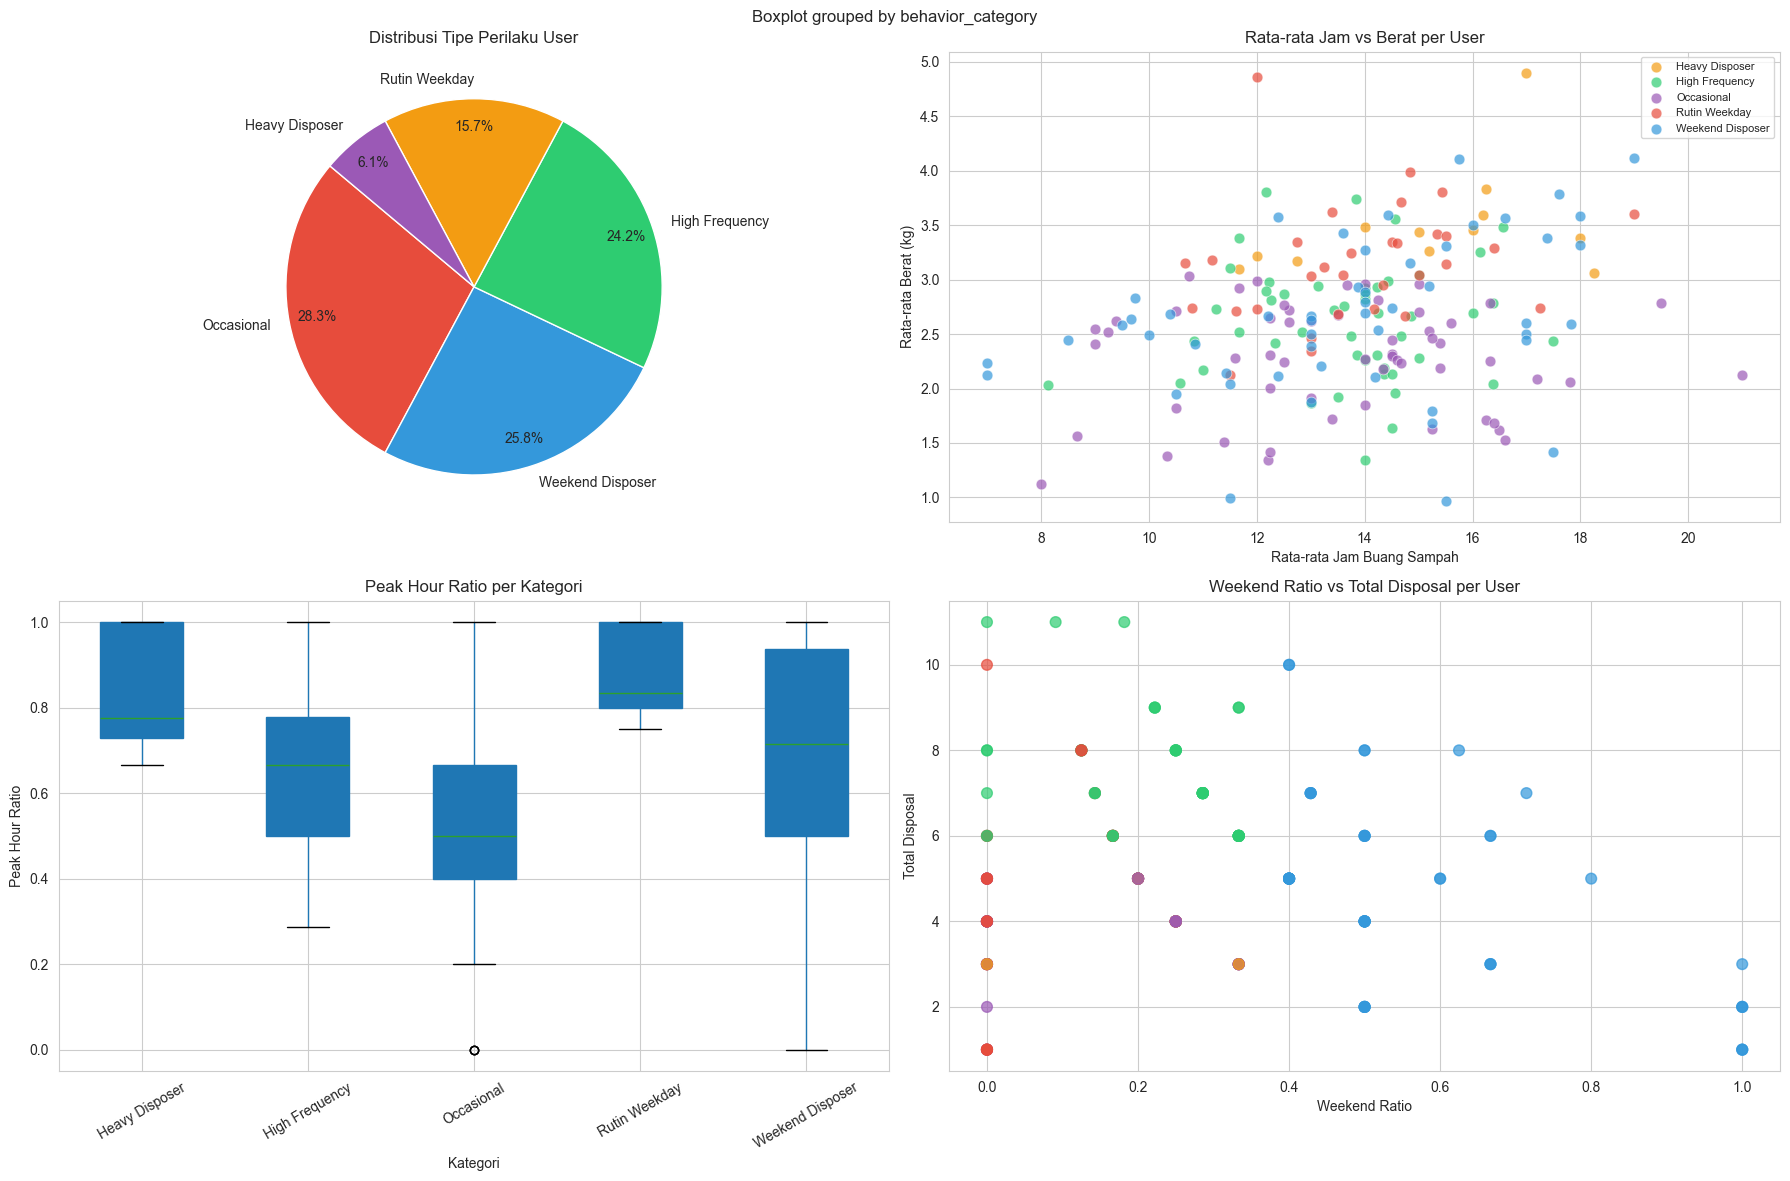


✅ user_stats tersimpan (shape: (198, 17) )
   Kolom tersedia: ['user_id', 'total_disposal', 'total_weight', 'avg_weight', 'std_weight', 'avg_hour', 'std_hour', 'peak_hour_ratio', 'weekend_ratio', 'rainy_ratio', 'avg_total_objects', 'avg_detected_count', 'unique_kecamatan', 'most_common_label', 'active_months', 'consistency_score', 'behavior_category']


In [ ]:
# ── 1. Aggregasi per user ─────────────────────────────────────────────────────
user_stats = df.groupby('user_id').agg(
    total_disposal=('record_id', 'count'),
    total_weight=('weight_kg', 'sum'),
    avg_weight=('weight_kg', 'mean'),
    std_weight=('weight_kg', 'std'),
    avg_hour=('hour', 'mean'),
    std_hour=('hour', 'std'),
    peak_hour_ratio=('is_peak_hour', 'mean'),
    weekend_ratio=('is_weekend', 'mean'),
    rainy_ratio=('is_rainy_season', 'mean'),
    avg_total_objects=('total_objects', 'mean'),
    avg_detected_count=('detected_count', 'mean'),
    unique_kecamatan=('kecamatan', 'nunique'),
    most_common_label=('detected_labels', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'unknown'),
    active_months=('month', 'nunique'),
).reset_index()

user_stats['std_weight'] = user_stats['std_weight'].fillna(0)
user_stats['std_hour'] = user_stats['std_hour'].fillna(0)
user_stats['consistency_score'] = 1 / (1 + user_stats['std_hour'])

print("=" * 55)
print("USER BEHAVIOR PATTERN SUMMARY")
print("=" * 55)
print(f"Total unique users: {user_stats['user_id'].nunique()}")
print(f"\nStatistik disposal per user:")
print(user_stats[['total_disposal','total_weight','avg_weight','peak_hour_ratio','weekend_ratio']].describe().round(2))

# ── 2. Kategorisasi behavior manual (sebelum clustering) ──────────────────────
def categorize_user(row):
    if row['peak_hour_ratio'] >= 0.75 and row['weekend_ratio'] < 0.2:
        return 'Rutin Weekday'
    elif row['weekend_ratio'] >= 0.4:
        return 'Weekend Disposer'
    elif row['total_disposal'] >= user_stats['total_disposal'].quantile(0.75):
        return 'High Frequency'
    elif row['avg_weight'] >= user_stats['avg_weight'].quantile(0.75):
        return 'Heavy Disposer'
    else:
        return 'Occasional'

user_stats['behavior_category'] = user_stats.apply(categorize_user, axis=1)

print("\nDistribusi Behavior Category (Pre-Clustering):")
print(user_stats['behavior_category'].value_counts())

# ── 3. Visualisasi behavior pattern ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('User Behavior Pattern Analysis', fontsize=16, fontweight='bold')

# Panel A: Distribusi behavior kategori
cat_counts = user_stats['behavior_category'].value_counts()
colors_pie = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
axes[0,0].pie(cat_counts.values, labels=cat_counts.index,
              autopct='%1.1f%%', colors=colors_pie[:len(cat_counts)],
              startangle=140, pctdistance=0.85)
axes[0,0].set_title('Distribusi Tipe Perilaku User', fontweight='bold')

# Panel B: Scatter avg_hour vs avg_weight, warna per kategori
cat_color_map = {
    'Rutin Weekday':'#E74C3C','Weekend Disposer':'#3498DB',
    'High Frequency':'#2ECC71','Heavy Disposer':'#F39C12','Occasional':'#9B59B6'
}
for cat, grp in user_stats.groupby('behavior_category'):
    axes[0,1].scatter(grp['avg_hour'], grp['avg_weight'],
                      label=cat, color=cat_color_map.get(cat,'grey'),
                      alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[0,1].set_title('Rata-rata Jam vs Berat per User', fontweight='bold')
axes[0,1].set_xlabel('Rata-rata Jam Buang Sampah')
axes[0,1].set_ylabel('Rata-rata Berat (kg)')
axes[0,1].legend(fontsize=8)

# Panel C: Peak hour ratio per behavior category
user_stats.boxplot(column='peak_hour_ratio', by='behavior_category', ax=axes[1,0],
                   patch_artist=True)
axes[1,0].set_title('Peak Hour Ratio per Kategori', fontweight='bold')
axes[1,0].set_xlabel('Kategori')
axes[1,0].set_ylabel('Peak Hour Ratio')
axes[1,0].tick_params(axis='x', rotation=30)
plt.sca(axes[1,0])
plt.title('Peak Hour Ratio per Kategori')

# Panel D: Total disposal vs weekend ratio
axes[1,1].scatter(user_stats['weekend_ratio'], user_stats['total_disposal'],
                  c=[list(cat_color_map.values())[i]
                     for i in user_stats['behavior_category'].map(
                         {k:j for j,k in enumerate(cat_color_map)})],
                  alpha=0.7, s=60)
axes[1,1].set_title('Weekend Ratio vs Total Disposal per User', fontweight='bold')
axes[1,1].set_xlabel('Weekend Ratio')
axes[1,1].set_ylabel('Total Disposal')

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/analysis_behavior_pattern.png", dpi=120, bbox_inches='tight')
plt.show()

# Simpan user_stats untuk dipakai clustering
print("\n✅ user_stats tersimpan (shape:", user_stats.shape, ")")
print("   Kolom tersedia:", list(user_stats.columns))

# **22. Feature Engineering untuk Clustering**

In [ ]:
from sklearn.preprocessing import StandardScaler

# ── Feature yang dipakai untuk clustering ────────────────────────────────────
# Dipilih berdasarkan relevansi behavioral pattern:
# avg_hour         → kapan user biasanya buang sampah
# std_hour         → konsistensi waktu (rendah = rutin)
# peak_hour_ratio  → seberapa sering di jam sibuk
# weekend_ratio    → pola hari kerja vs libur
# avg_weight       → jumlah sampah per kunjungan
# total_disposal   → frekuensi keseluruhan
# avg_total_objects→ variasi jenis per kunjungan

CLUSTER_FEATURES = [
    'avg_hour',
    'std_hour',
    'peak_hour_ratio',
    'weekend_ratio',
    'avg_weight',
    'total_disposal',
    'avg_total_objects',
]

X_cluster = user_stats[CLUSTER_FEATURES].copy()
X_cluster = X_cluster.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("=" * 55)
print("FEATURE ENGINEERING UNTUK CLUSTERING")
print("=" * 55)
print(f"Features: {CLUSTER_FEATURES}")
print(f"Shape setelah scaling: {X_scaled.shape}")
print(f"\nStatistik X_cluster sebelum scaling:")
print(X_cluster.describe().round(3))

FEATURE ENGINEERING UNTUK CLUSTERING
Features: ['avg_hour', 'std_hour', 'peak_hour_ratio', 'weekend_ratio', 'avg_weight', 'total_disposal', 'avg_total_objects']
Shape setelah scaling: (198, 7)

Statistik X_cluster sebelum scaling:
       avg_hour  std_hour  peak_hour_ratio  weekend_ratio  avg_weight  \
count   198.000   198.000          198.000        198.000     198.000   
mean     13.765     4.649            0.676          0.268       2.666   
std       2.428     1.820            0.241          0.232       0.665   
min       7.000     0.000            0.000          0.000       0.970   
25%      12.250     3.676            0.500          0.125       2.250   
50%      14.000     4.960            0.714          0.250       2.672   
75%      15.250     5.690            0.833          0.400       3.059   
max      21.000     9.487            1.000          1.000       4.898   

       total_disposal  avg_total_objects  
count         198.000            198.000  
mean            5.101    

# **23. K-Means Clustering**

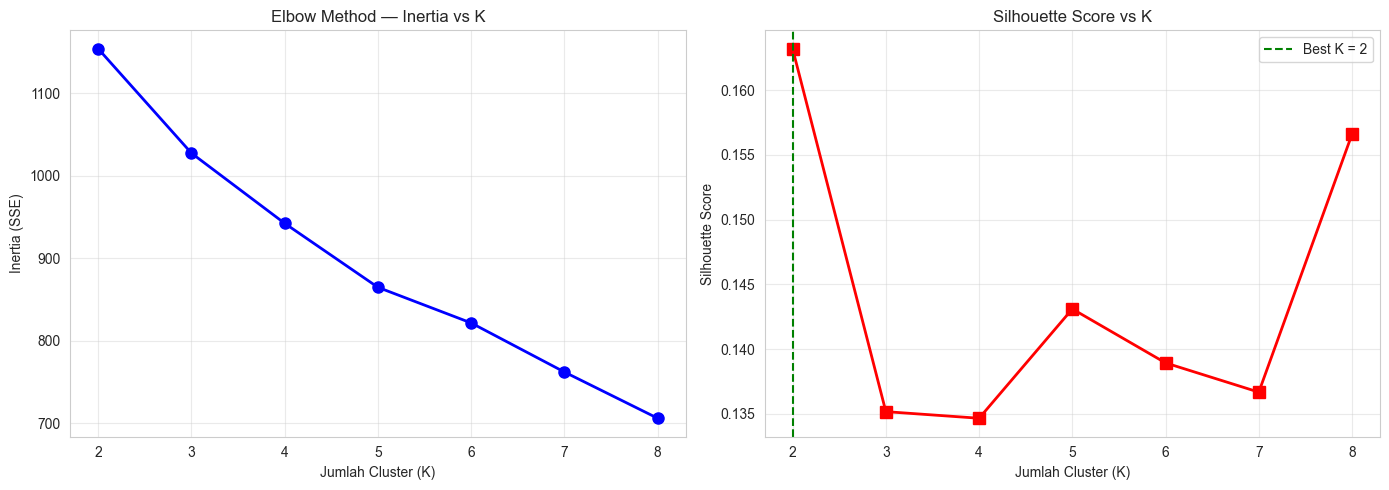

K optimal berdasarkan Silhouette Score: K = 2
Silhouette Score @ K=2: 0.1632

=== PROFIL K-MEANS CLUSTER ===
                avg_hour  std_hour  peak_hour_ratio  weekend_ratio  avg_weight  total_disposal  avg_total_objects  size
kmeans_cluster                                                                                                         
0                 14.417     3.874            0.884          0.311       3.194           4.468              4.588    79
1                 13.333     5.164            0.538          0.240       2.316           5.521              4.753   119

Distribusi label K-Means:
kmeans_label
C1: High Frequency    119
C0: High Frequency     79
Name: count, dtype: int64


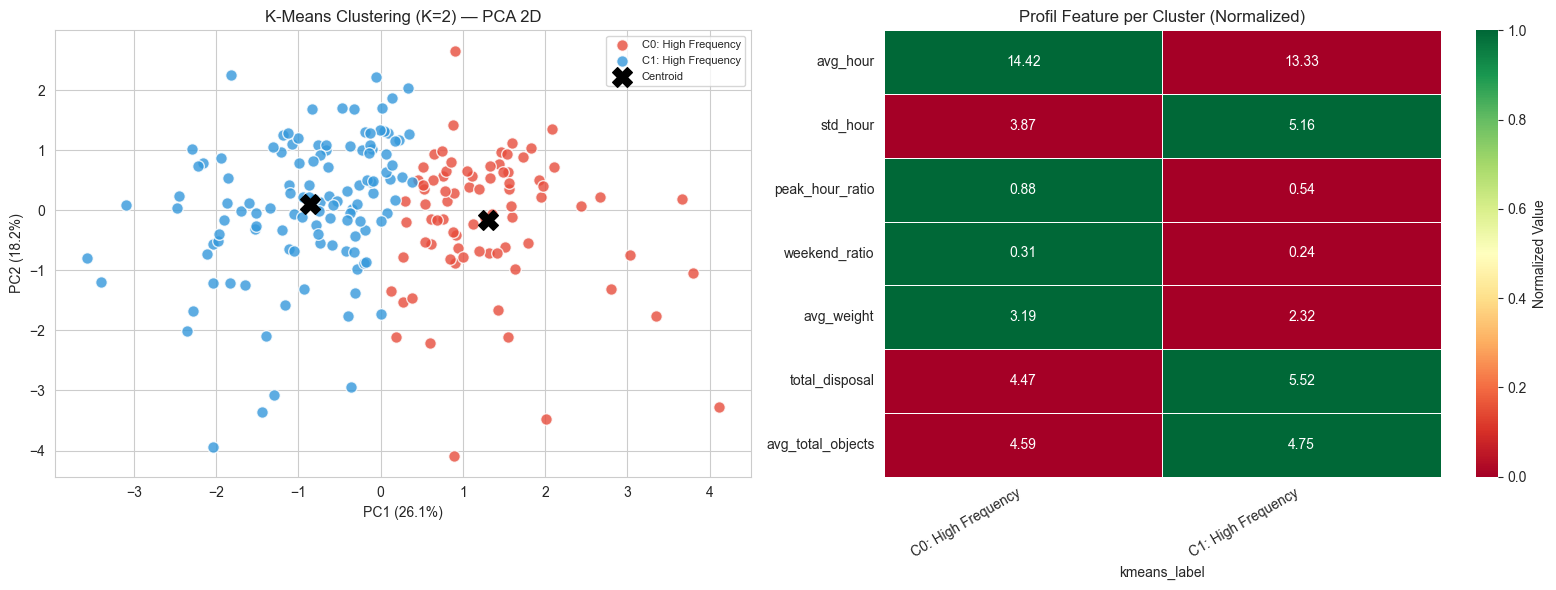


✅ K-Means selesai. Silhouette Score = 0.1632


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ── 1. Elbow Method + Silhouette untuk cari K optimal ────────────────────────
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia (SSE)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(k_range, silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.4)

best_k = k_range[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Best K = {best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/kmeans_elbow_silhouette.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"K optimal berdasarkan Silhouette Score: K = {best_k}")
print(f"Silhouette Score @ K={best_k}: {max(silhouettes):.4f}")

# ── 2. Fit K-Means dengan K optimal ──────────────────────────────────────────
K_OPTIMAL = best_k
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
user_stats['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# ── 3. Analisis karakteristik tiap cluster ────────────────────────────────────
cluster_profile = user_stats.groupby('kmeans_cluster')[CLUSTER_FEATURES].mean().round(3)
cluster_profile['size'] = user_stats['kmeans_cluster'].value_counts().sort_index()
print("\n=== PROFIL K-MEANS CLUSTER ===")
print(cluster_profile.to_string())

# ── 4. Labeling cluster berdasarkan profil ────────────────────────────────────
def label_kmeans_cluster(row, profile_df):
    c = row['kmeans_cluster']
    p = profile_df.loc[c]
    if p['peak_hour_ratio'] >= 0.70 and p['weekend_ratio'] < 0.25:
        return f'C{c}: Weekday Routine'
    elif p['weekend_ratio'] >= 0.35:
        return f'C{c}: Weekend Active'
    elif p['total_disposal'] >= profile_df['total_disposal'].max() * 0.7:
        return f'C{c}: High Frequency'
    elif p['avg_weight'] >= profile_df['avg_weight'].max() * 0.7:
        return f'C{c}: Heavy Waste'
    else:
        return f'C{c}: Occasional'

user_stats['kmeans_label'] = user_stats.apply(
    lambda r: label_kmeans_cluster(r, cluster_profile), axis=1)

print("\nDistribusi label K-Means:")
print(user_stats['kmeans_label'].value_counts())

# ── 5. Visualisasi cluster ───────────────────────────────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
user_stats['pca_x'] = X_pca[:, 0]
user_stats['pca_y'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C','#E67E22']

# PCA scatter
for c in sorted(user_stats['kmeans_cluster'].unique()):
    mask = user_stats['kmeans_cluster'] == c
    label = user_stats.loc[mask, 'kmeans_label'].iloc[0]
    axes[0].scatter(user_stats.loc[mask,'pca_x'], user_stats.loc[mask,'pca_y'],
                    label=label, color=palette[c], alpha=0.8, s=70, edgecolors='white')

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:,0], centroids_pca[:,1],
                c='black', marker='X', s=200, zorder=5, label='Centroid')
axes[0].set_title(f'K-Means Clustering (K={K_OPTIMAL}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=8, loc='best')

# Heatmap profil cluster
import seaborn as sns
cluster_heatmap = user_stats.groupby('kmeans_label')[CLUSTER_FEATURES].mean()
cluster_heatmap_norm = (cluster_heatmap - cluster_heatmap.min()) / (cluster_heatmap.max() - cluster_heatmap.min())
sns.heatmap(cluster_heatmap_norm.T, ax=axes[1], cmap='RdYlGn',
            annot=cluster_heatmap.T.round(2), fmt='.2f',
            linewidths=0.5, cbar_kws={'label':'Normalized Value'})
axes[1].set_title('Profil Feature per Cluster (Normalized)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/kmeans_clustering_result.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✅ K-Means selesai. Silhouette Score = {silhouette_score(X_scaled, user_stats['kmeans_cluster']):.4f}")

# **24. DBSCAN Clustering**

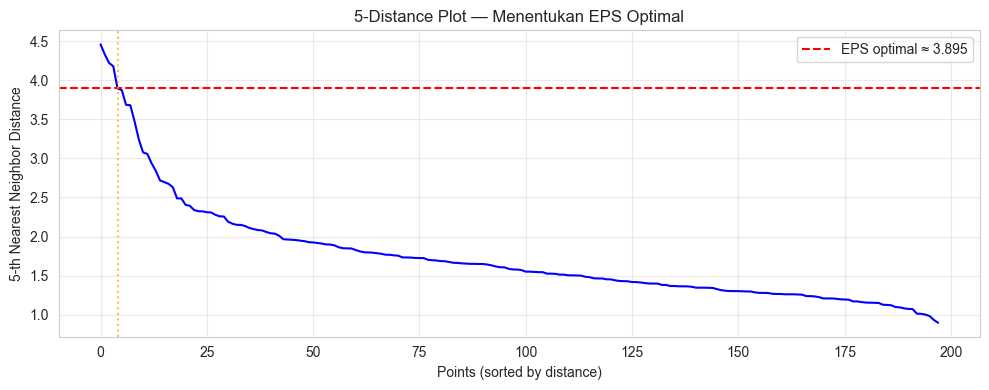

EPS optimal terdeteksi: 3.895

=== DBSCAN RESULT ===
Jumlah cluster terbentuk: 1
Noise points (outlier): 0 (0.0%)
Points dalam cluster: 198 (100.0%)

Distribusi cluster:
dbscan_cluster
0    198
Name: count, dtype: int64

[!] Tidak cukup cluster untuk menghitung Silhouette Score
    → Coba sesuaikan eps atau min_samples secara manual


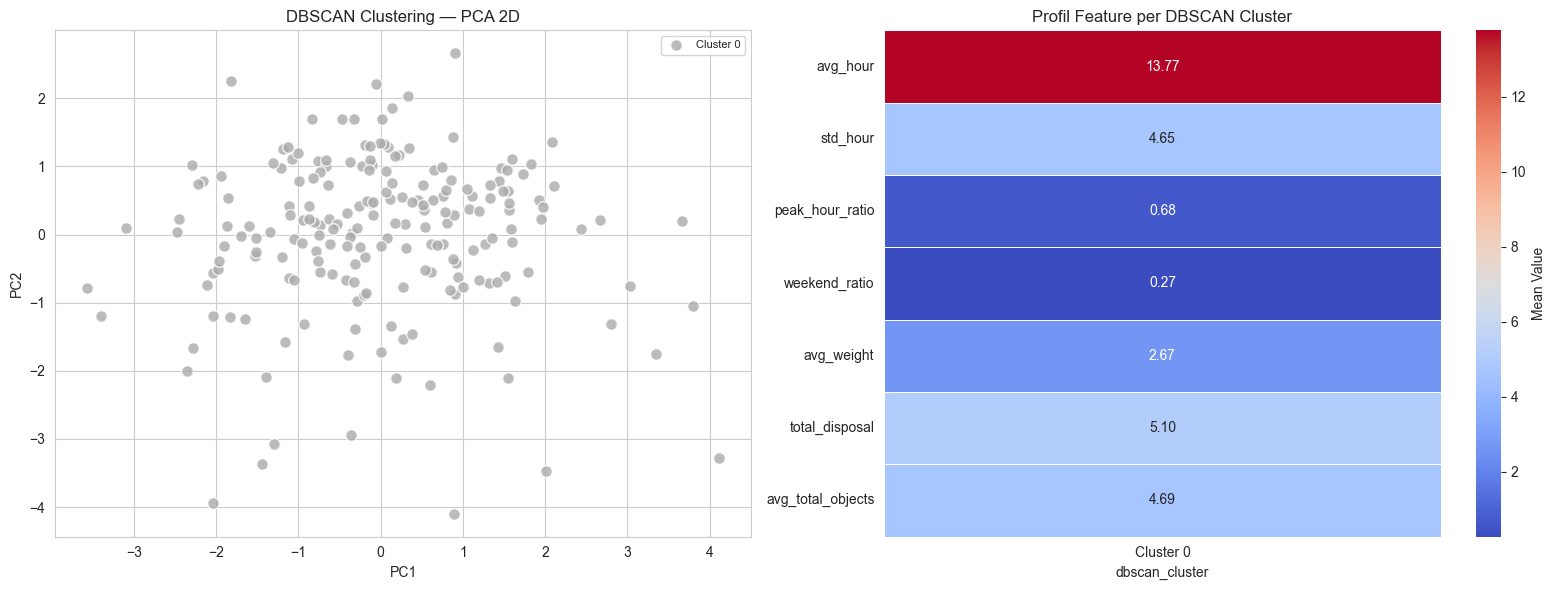


✅ DBSCAN selesai.


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# ── 1. Cari eps optimal dengan k-distance plot ───────────────────────────────
k_neighbors = 5  # aturan praktis: min_samples = 2 * n_features - 1 ≈ 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, k_neighbors-1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, 'b-', linewidth=1.5)
ax.set_title(f'{k_neighbors}-Distance Plot — Menentukan EPS Optimal', fontweight='bold')
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k_neighbors}-th Nearest Neighbor Distance')
ax.grid(True, alpha=0.4)

# Cari "elbow" secara otomatis (titik infleksi maksimum)
diffs = np.diff(k_dist)
elbow_idx = np.argmax(np.abs(np.diff(diffs))) + 1
eps_optimal = round(k_dist[elbow_idx], 3)
ax.axhline(eps_optimal, color='red', linestyle='--', linewidth=1.5,
           label=f'EPS optimal ≈ {eps_optimal}')
ax.axvline(elbow_idx, color='orange', linestyle=':', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/dbscan_kdistance.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"EPS optimal terdeteksi: {eps_optimal}")

# ── 2. Fit DBSCAN ────────────────────────────────────────────────────────────
MIN_SAMPLES = max(3, len(CLUSTER_FEATURES) - 1)
dbscan = DBSCAN(eps=eps_optimal, min_samples=MIN_SAMPLES)
user_stats['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(user_stats['dbscan_cluster'])) - (1 if -1 in user_stats['dbscan_cluster'].values else 0)
n_noise = (user_stats['dbscan_cluster'] == -1).sum()
n_clustered = len(user_stats) - n_noise

print("\n=== DBSCAN RESULT ===")
print(f"Jumlah cluster terbentuk: {n_clusters_db}")
print(f"Noise points (outlier): {n_noise} ({n_noise/len(user_stats)*100:.1f}%)")
print(f"Points dalam cluster: {n_clustered} ({n_clustered/len(user_stats)*100:.1f}%)")
print("\nDistribusi cluster:")
print(user_stats['dbscan_cluster'].value_counts().sort_index())

if n_clustered > 1 and n_clusters_db >= 2:
    valid_mask = user_stats['dbscan_cluster'] != -1
    db_sil = silhouette_score(X_scaled[valid_mask], user_stats.loc[valid_mask, 'dbscan_cluster'])
    print(f"\nSilhouette Score (non-noise): {db_sil:.4f}")
else:
    db_sil = None
    print("\n[!] Tidak cukup cluster untuk menghitung Silhouette Score")
    print("    → Coba sesuaikan eps atau min_samples secara manual")

# ── 3. Visualisasi DBSCAN ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot DBSCAN
db_labels = user_stats['dbscan_cluster']
unique_labels = sorted(db_labels.unique())
db_palette = ['#AAAAAA'] + ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6','#1ABC9C']

for i, lbl in enumerate(unique_labels):
    mask = db_labels == lbl
    color = '#AAAAAA' if lbl == -1 else db_palette[i % len(db_palette)]
    lab = 'Noise/Outlier' if lbl == -1 else f'Cluster {lbl}'
    axes[0].scatter(user_stats.loc[mask,'pca_x'], user_stats.loc[mask,'pca_y'],
                    label=lab, color=color, alpha=0.8, s=70, edgecolors='white',
                    marker='x' if lbl == -1 else 'o')

axes[0].set_title('DBSCAN Clustering — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)

# Profil DBSCAN cluster (tanpa noise)
db_profile = user_stats[user_stats['dbscan_cluster'] != -1].groupby('dbscan_cluster')[CLUSTER_FEATURES].mean().round(3)
if not db_profile.empty:
    sns.heatmap(db_profile.T, ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f',
                linewidths=0.5, cbar_kws={'label':'Mean Value'})
    axes[1].set_title('Profil Feature per DBSCAN Cluster', fontweight='bold')
    axes[1].set_xticklabels([f'Cluster {c}' for c in db_profile.index], rotation=0)
    axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
else:
    axes[1].text(0.5, 0.5, 'Tidak ada cluster valid', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/dbscan_clustering_result.png", dpi=120, bbox_inches='tight')
plt.show()

# ── 4. Analisis outlier DBSCAN ───────────────────────────────────────────────
if n_noise > 0:
    outliers = user_stats[user_stats['dbscan_cluster'] == -1][['user_id'] + CLUSTER_FEATURES]
    print("\n=== OUTLIER / ANOMALI (DBSCAN Noise) ===")
    print(f"Total outlier: {n_noise} users")
    print(outliers[['user_id','avg_hour','avg_weight','total_disposal','peak_hour_ratio']].to_string(index=False))
    print("\n💡 Interpretasi: User outlier memiliki pola yang sangat berbeda dari mayoritas.")
    print("   Kemungkinan: jam buang sangat tidak biasa, berat ekstrem, atau frekuensi sangat rendah/tinggi.")

print("\n✅ DBSCAN selesai.")

# **25. Perbandingan K-Means vs DBSCAN & Interpretasi**

In [ ]:
print("=" * 60)
print("PERBANDINGAN K-MEANS vs DBSCAN")
print("=" * 60)

km_sil = silhouette_score(X_scaled, user_stats['kmeans_cluster'])
print(f"\nK-Means  | K = {K_OPTIMAL} cluster | Silhouette = {km_sil:.4f}")

if db_sil is not None:
    print(f"DBSCAN   | {n_clusters_db} cluster + {n_noise} noise | Silhouette = {db_sil:.4f}")
else:
    print(f"DBSCAN   | {n_clusters_db} cluster + {n_noise} noise | Silhouette = N/A")

print("""
📌 INTERPRETASI AKADEMIK:
─────────────────────────────────────────────────────────
K-Means → Membagi semua user ke dalam K kelompok perilaku.
          Berguna untuk segmentasi rutin & perencanaan jadwal.

DBSCAN  → Menemukan cluster tanpa asumsi bentuk & jumlah.
          Berguna untuk mendeteksi anomali (noise points).
          Noise = user dengan pola sangat tidak biasa
          → potensial untuk sistem peringatan dini.

Kombinasi keduanya memberikan insight lebih kaya:
  • K-Means: segmentasi populasi utama
  • DBSCAN:  deteksi outlier & pola tidak lazim
─────────────────────────────────────────────────────────
""")

# Gabungkan hasil clustering ke df utama (via merge user_id)
df = df.merge(
    user_stats[['user_id','kmeans_cluster','kmeans_label','dbscan_cluster','behavior_category']],
    on='user_id', how='left'
)

print("✅ Hasil clustering berhasil di-merge ke df utama.")
print("   Kolom baru:", ['kmeans_cluster','kmeans_label','dbscan_cluster','behavior_category'])

PERBANDINGAN K-MEANS vs DBSCAN

K-Means  | K = 2 cluster | Silhouette = 0.1632
DBSCAN   | 1 cluster + 0 noise | Silhouette = N/A

📌 INTERPRETASI AKADEMIK:
─────────────────────────────────────────────────────────
K-Means → Membagi semua user ke dalam K kelompok perilaku.
          Berguna untuk segmentasi rutin & perencanaan jadwal.

DBSCAN  → Menemukan cluster tanpa asumsi bentuk & jumlah.
          Berguna untuk mendeteksi anomali (noise points).
          Noise = user dengan pola sangat tidak biasa
          → potensial untuk sistem peringatan dini.

Kombinasi keduanya memberikan insight lebih kaya:
  • K-Means: segmentasi populasi utama
  • DBSCAN:  deteksi outlier & pola tidak lazim
─────────────────────────────────────────────────────────

✅ Hasil clustering berhasil di-merge ke df utama.
   Kolom baru: ['kmeans_cluster', 'kmeans_label', 'dbscan_cluster', 'behavior_category']


# **26. Persiapan Data Time Series untuk Prophet**

Menyiapkan data time series harian...
Rentang waktu: 2025-01-01 → 2025-12-31
Jumlah hari: 365
Total berat rata-rata harian: 7.40 kg

Preview:
        ds     y  disposal_count  avg_weight
2025-01-01 11.01             3.0      3.6700
2025-01-02  2.03             1.0      2.0300
2025-01-03  0.40             1.0      0.4000
2025-01-04 12.05             4.0      3.0125
2025-01-05 13.63             5.0      2.7260
2025-01-06  7.32             2.0      3.6600
2025-01-07 13.78             4.0      3.4450
2025-01-08 11.94             5.0      2.3880
2025-01-09 15.02             4.0      3.7550
2025-01-10 14.86             4.0      3.7150


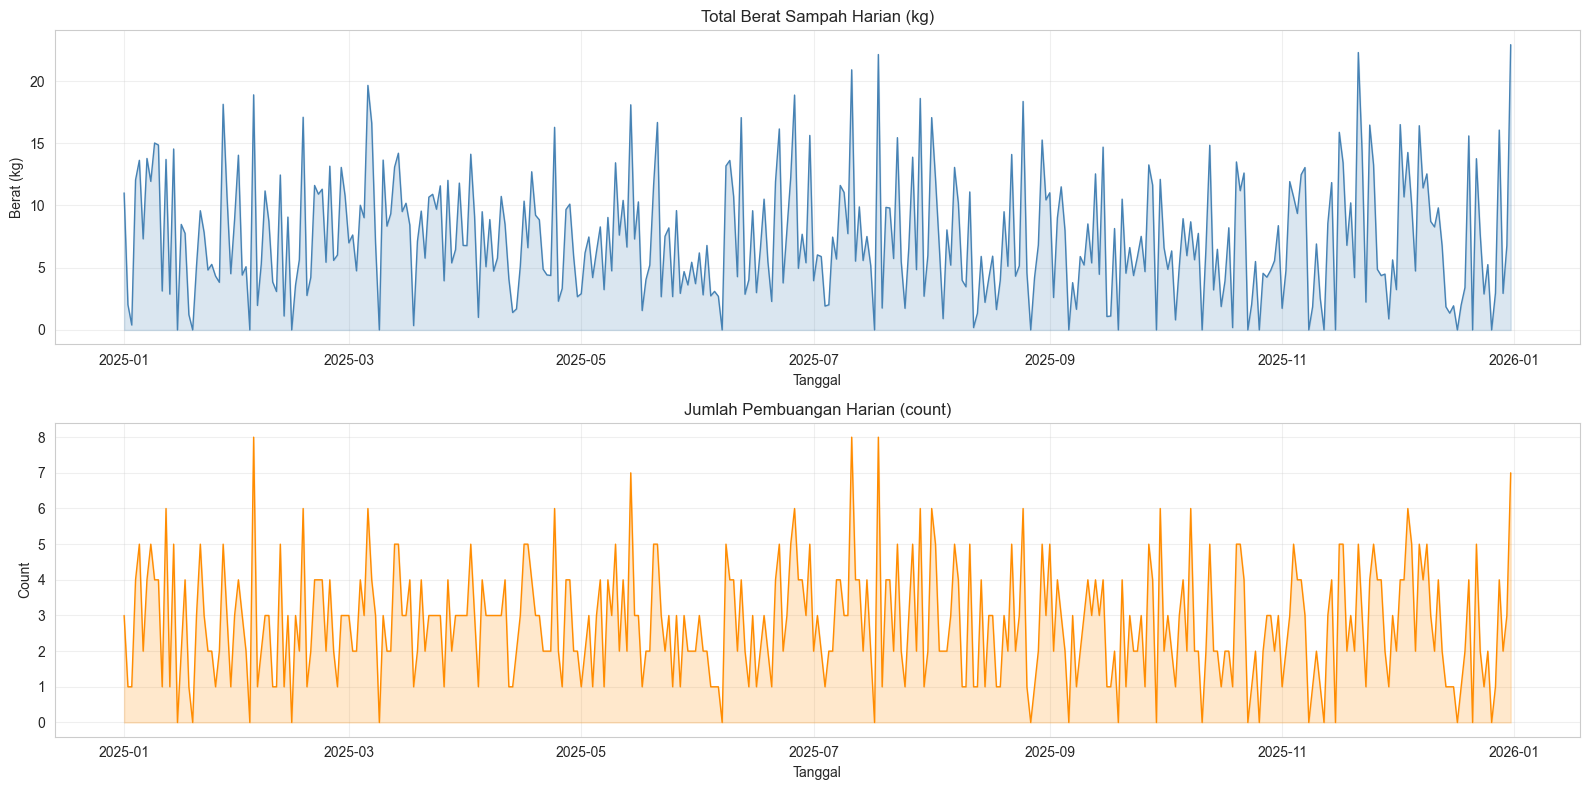

In [ ]:
!pip install prophet -q

print("Menyiapkan data time series harian...")

df['date'] = pd.to_datetime(df['date'])

# Agregasi harian: total weight dan total disposal count
daily_ts = df.groupby('date').agg(
    y=('weight_kg', 'sum'),          # total berat harian
    disposal_count=('record_id','count'),
    avg_weight=('weight_kg','mean'),
).reset_index().rename(columns={'date':'ds'})

daily_ts = daily_ts.sort_values('ds').reset_index(drop=True)

# Pastikan tidak ada gap tanggal (fill 0 jika perlu)
full_dates = pd.DataFrame({'ds': pd.date_range(
    daily_ts['ds'].min(), daily_ts['ds'].max(), freq='D')})
daily_ts = full_dates.merge(daily_ts, on='ds', how='left').fillna(0)
daily_ts['ds'] = pd.to_datetime(daily_ts['ds'])

print(f"Rentang waktu: {daily_ts['ds'].min().date()} → {daily_ts['ds'].max().date()}")
print(f"Jumlah hari: {len(daily_ts)}")
print(f"Total berat rata-rata harian: {daily_ts['y'].mean():.2f} kg")
print(f"\nPreview:")
print(daily_ts.head(10).to_string(index=False))

# Plot time series harian
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes[0].plot(daily_ts['ds'], daily_ts['y'], color='steelblue', linewidth=1)
axes[0].fill_between(daily_ts['ds'], daily_ts['y'], alpha=0.2, color='steelblue')
axes[0].set_title('Total Berat Sampah Harian (kg)', fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Berat (kg)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_ts['ds'], daily_ts['disposal_count'], color='darkorange', linewidth=1)
axes[1].fill_between(daily_ts['ds'], daily_ts['disposal_count'], alpha=0.2, color='darkorange')
axes[1].set_title('Jumlah Pembuangan Harian (count)', fontweight='bold')
axes[1].set_xlabel('Tanggal')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/timeseries_daily.png", dpi=120, bbox_inches='tight')
plt.show()

# **27. Prophet Forecasting**

Train: 292 hari | Test: 73 hari

=== EVALUASI PROPHET ===
MAE  : 5.245 kg
RMSE : 6.910 kg
MAPE : 39155428760.35 %


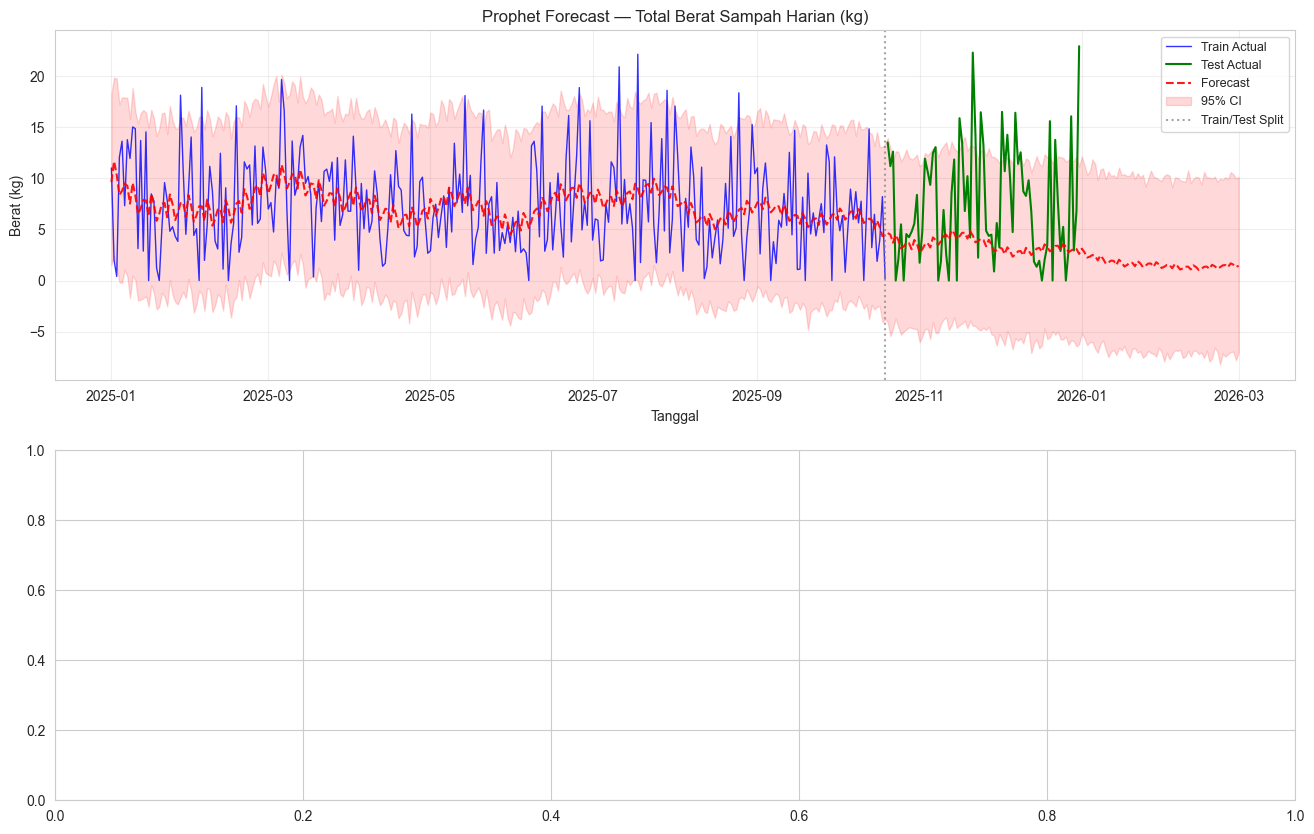

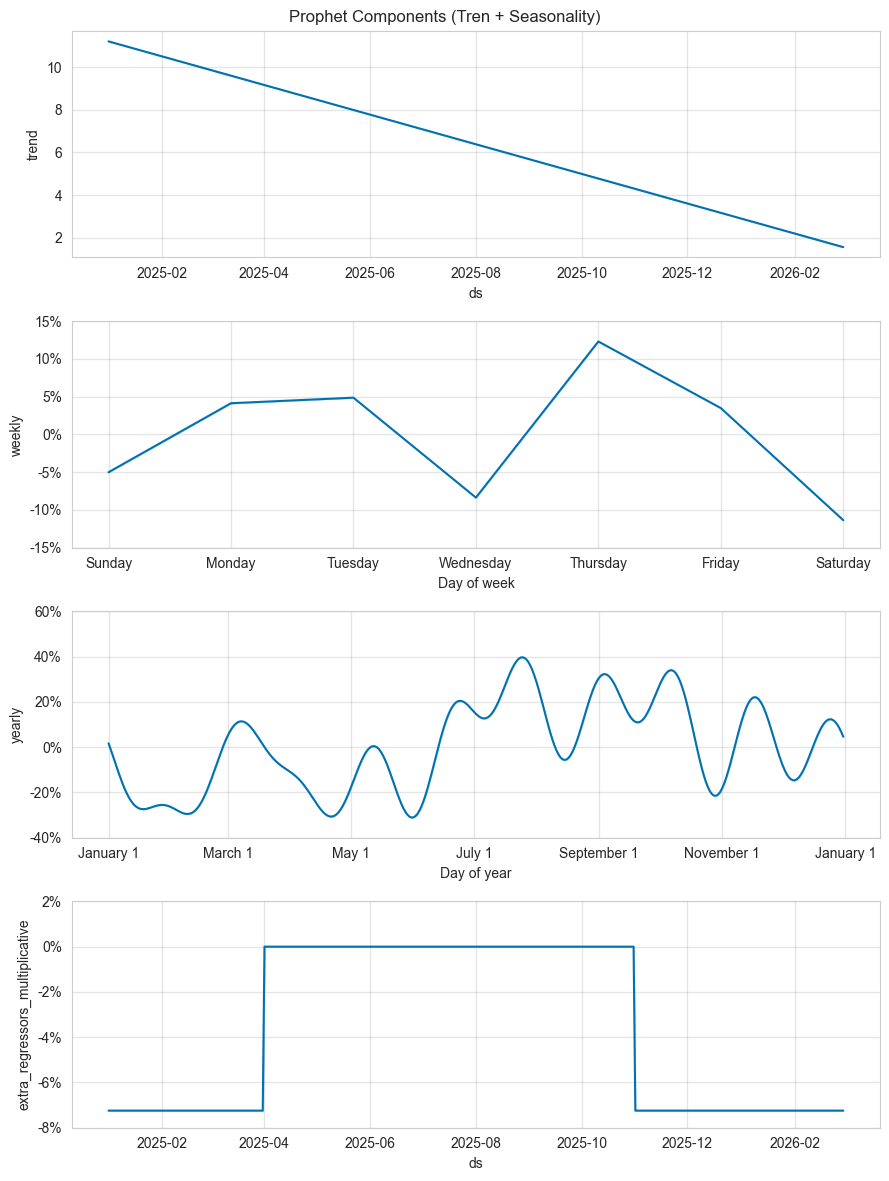


✅ Prophet selesai.
   Forecast 60 hari ke depan tersimpan di variabel 'forecast'


In [ ]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── 1. Split train / test (80:20) ────────────────────────────────────────────
split_idx = int(len(daily_ts) * 0.8)
train_ts = daily_ts.iloc[:split_idx][['ds','y']].copy()
test_ts  = daily_ts.iloc[split_idx:][['ds','y']].copy()

print(f"Train: {len(train_ts)} hari | Test: {len(test_ts)} hari")

# ── 2. Bangun model Prophet ──────────────────────────────────────────────────
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',   # cocok untuk data dengan variasi musiman
    changepoint_prior_scale=0.05,        # regularisasi perubahan tren
    seasonality_prior_scale=10.0,
    interval_width=0.95
)

# Tambahkan regressors bulan (musim hujan Bekasi: Nov–Mar)
train_ts['is_rainy_month'] = train_ts['ds'].dt.month.isin([11,12,1,2,3]).astype(int)
prophet_model.add_regressor('is_rainy_month', standardize=False)

prophet_model.fit(train_ts)

# ── 3. Buat future dataframe (test + 60 hari ke depan) ───────────────────────
future_periods = len(test_ts) + 60
future = prophet_model.make_future_dataframe(periods=future_periods, freq='D')
future['is_rainy_month'] = future['ds'].dt.month.isin([11,12,1,2,3]).astype(int)

forecast = prophet_model.predict(future)

# ── 4. Evaluasi pada test set ────────────────────────────────────────────────
forecast_test = forecast[forecast['ds'].isin(test_ts['ds'])][['ds','yhat','yhat_lower','yhat_upper']]
eval_df = test_ts.merge(forecast_test, on='ds', how='inner')

mae  = mean_absolute_error(eval_df['y'], eval_df['yhat'])
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))
mape = np.mean(np.abs((eval_df['y'] - eval_df['yhat']) / (eval_df['y'] + 1e-9))) * 100

print("\n=== EVALUASI PROPHET ===")
print(f"MAE  : {mae:.3f} kg")
print(f"RMSE : {rmse:.3f} kg")
print(f"MAPE : {mape:.2f} %")

# ── 5. Visualisasi forecast ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel A: Forecast lengkap
ax = axes[0]
ax.plot(train_ts['ds'], train_ts['y'], 'b-', linewidth=1, label='Train Actual', alpha=0.8)
ax.plot(test_ts['ds'], test_ts['y'], 'g-', linewidth=1.5, label='Test Actual')
ax.plot(forecast['ds'], forecast['yhat'], 'r--', linewidth=1.5, label='Forecast', alpha=0.9)
ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                alpha=0.15, color='red', label='95% CI')
ax.axvline(train_ts['ds'].max(), color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')
ax.set_title('Prophet Forecast — Total Berat Sampah Harian (kg)', fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Berat (kg)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel B: Komponen seasonality
fig2 = prophet_model.plot_components(forecast)
fig2.suptitle('Prophet Components (Tren + Seasonality)', fontweight='bold')
fig2.savefig(f"{PROJECT_DIR}/prophet_components.png", dpi=120, bbox_inches='tight')

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/prophet_forecast.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✅ Prophet selesai.")
print(f"   Forecast 60 hari ke depan tersimpan di variabel 'forecast'")

# **28. Prophet Model Cross-Validation**

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(
    prophet_model,
    initial='180 days',
    period='30 days',
    horizon='30 days',
    parallel="processes"
)
df_p = performance_metrics(df_cv)

# Dynamically select columns to print, only including 'mape' if it exists
columns_to_print = ['horizon', 'mae', 'rmse']
if 'mape' in df_p.columns:
    columns_to_print.append('mape')

print(df_p[columns_to_print].tail(10))

INFO:prophet:Making 3 forecasts with cutoffs between 2025-07-21 00:00:00 and 2025-09-19 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7d5a439b8d40>
INFO:prophet:Skipping MAPE because y close to 0


   horizon       mae      rmse
18 21 days  3.138174  3.506614
19 22 days  3.121053  3.765425
20 23 days  3.455633  4.037042
21 24 days  4.449300  5.235966
22 25 days  4.194283  4.799269
23 26 days  4.284766  4.983361
24 27 days  3.662596  4.253302
25 28 days  3.893382  4.559737
26 29 days  3.533801  4.177115
27 30 days  3.858303  4.409910


# **29. Persiapan Data untuk LSTM**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# ── 1. Siapkan feature multivariate untuk LSTM ───────────────────────────────
# LSTM akan memprediksi total_weight harian
# Input features: weight, disposal_count, is_rainy, day_of_week, month

lstm_daily = df.groupby('date').agg(
    weight=('weight_kg','sum'),
    count=('record_id','count'),
    avg_objects=('total_objects','mean'),
).reset_index()

# Tambahkan fitur temporal
lstm_daily['date'] = pd.to_datetime(lstm_daily['date'])
lstm_daily = lstm_daily.sort_values('date').reset_index(drop=True)
lstm_daily['dayofweek'] = lstm_daily['date'].dt.dayofweek
lstm_daily['month'] = lstm_daily['date'].dt.month
lstm_daily['is_weekend'] = (lstm_daily['dayofweek'] >= 5).astype(int)
lstm_daily['is_rainy'] = lstm_daily['month'].isin([11,12,1,2,3]).astype(int)

# Fill gap tanggal
full_dates = pd.date_range(lstm_daily['date'].min(), lstm_daily['date'].max(), freq='D')
lstm_daily = lstm_daily.set_index('date').reindex(full_dates).reset_index()
lstm_daily.columns = ['date'] + list(lstm_daily.columns[1:])
lstm_daily = lstm_daily.fillna(method='ffill').fillna(0)
lstm_daily['dayofweek'] = lstm_daily['date'].dt.dayofweek
lstm_daily['month'] = lstm_daily['date'].dt.month
lstm_daily['is_weekend'] = (lstm_daily['dayofweek'] >= 5).astype(int)
lstm_daily['is_rainy'] = lstm_daily['month'].isin([11,12,1,2,3]).astype(int)

LSTM_FEATURES = ['weight','count','avg_objects','dayofweek','is_weekend','is_rainy']
TARGET_COL = 'weight'
LOOKBACK = 14   # 2 minggu history sebagai input sequence

# ── 2. Normalisasi ────────────────────────────────────────────────────────────
lstm_scaler = MinMaxScaler()
lstm_scaled = lstm_scaler.fit_transform(lstm_daily[LSTM_FEATURES])

target_scaler = MinMaxScaler()
target_scaled = target_scaler.fit_transform(lstm_daily[[TARGET_COL]])

# ── 3. Buat sequences ─────────────────────────────────────────────────────────
def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(lstm_scaled, target_scaled, LOOKBACK)

# ── 4. Split 80:20 ────────────────────────────────────────────────────────────
split = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("=" * 55)
print("PERSIAPAN DATA LSTM")
print("=" * 55)
print(f"Total hari: {len(lstm_daily)}")
print(f"Lookback window: {LOOKBACK} hari")
print(f"Total sequences: {len(X_seq)}")
print(f"X_train shape: {X_train.shape}  | y_train: {y_train.shape}")
print(f"X_test shape : {X_test.shape}   | y_test : {y_test.shape}")
print(f"Features: {LSTM_FEATURES}")

PERSIAPAN DATA LSTM
Total hari: 365
Lookback window: 14 hari
Total sequences: 351
X_train shape: (280, 14, 6)  | y_train: (280, 1)
X_test shape : (71, 14, 6)   | y_test : (71, 1)
Features: ['weight', 'count', 'avg_objects', 'dayofweek', 'is_weekend', 'is_rainy']


# **30. LSTM Training**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,265 (122.13 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - loss: 0.0853 - mae: 0.2183 - val_loss: 0.0909 - val_mae: 0.2573 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0656 - mae: 0.2061 - val_loss: 0.0881 - val_mae: 0.2528 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0570 - mae: 0.1923 - val_loss: 0.0798 - val_mae: 0.2388 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0530 - mae: 0.1827 - val_loss: 0.0693 - val_mae: 0.2203 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0501 - mae: 0.1787 - val_loss: 0.0691 - val_mae: 0.2199 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0453 - mae: 0.1695 - val_loss: 0.0602 - val_mae: 0.2022 - learning_rate: 0.0010
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0460 - mae: 0.1718 - val_loss: 0.0664 - val_mae: 0.2147 - learning_rate: 0.0010
Epoch 

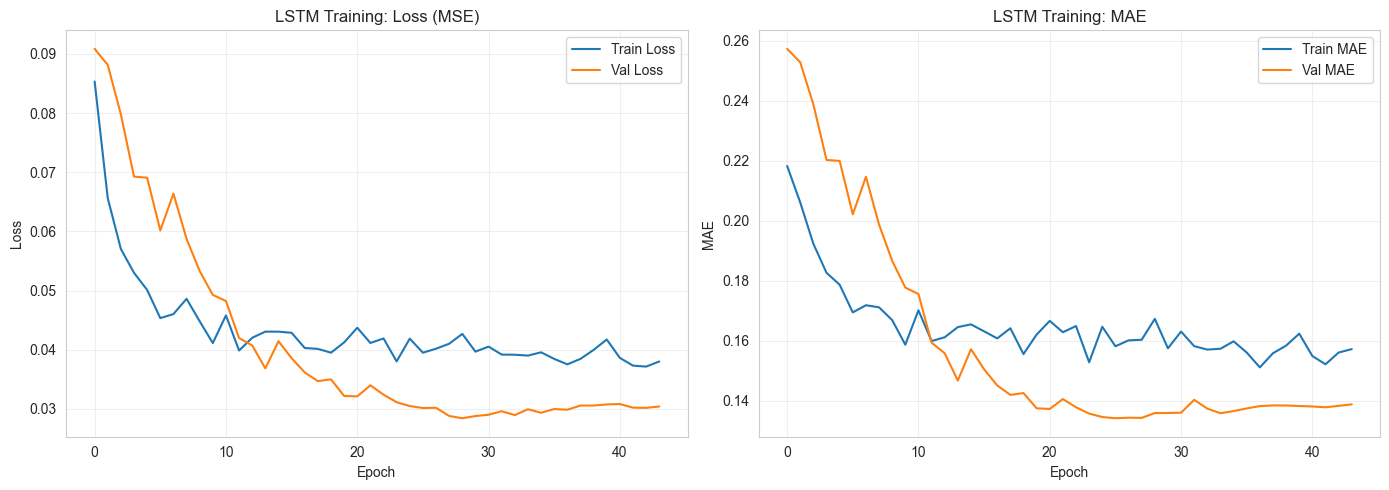


✅ LSTM training selesai. Model disimpan ke: /content/drive/MyDrive/disposal_waste_final/lstm_best_model.keras


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)

# ── 1. Bangun arsitektur LSTM ─────────────────────────────────────────────────
model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, len(LSTM_FEATURES))),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])
model_lstm.summary()

# ── 2. Callbacks ──────────────────────────────────────────────────────────────
LSTM_MODEL_PATH = f"{PROJECT_DIR}/lstm_best_model.keras"

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint(LSTM_MODEL_PATH, save_best_only=True, monitor='val_loss', verbose=0),
]

# ── 3. Training ───────────────────────────────────────────────────────────────
history = model_lstm.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

# ── 4. Plot training history ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM Training: Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('LSTM Training: MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/lstm_training_history.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✅ LSTM training selesai. Model disimpan ke: {LSTM_MODEL_PATH}")

# **31. LSTM Evaluation & Forecast**

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
EVALUASI LSTM
MAE  : 4.655 kg
RMSE : 5.524 kg
MAPE : 93.08 %

--- Perbandingan Prophet vs LSTM ---
Model           MAE     RMSE     MAPE
Prophet       5.245    6.910 39155428760.35%
LSTM          4.655    5.524   93.08%


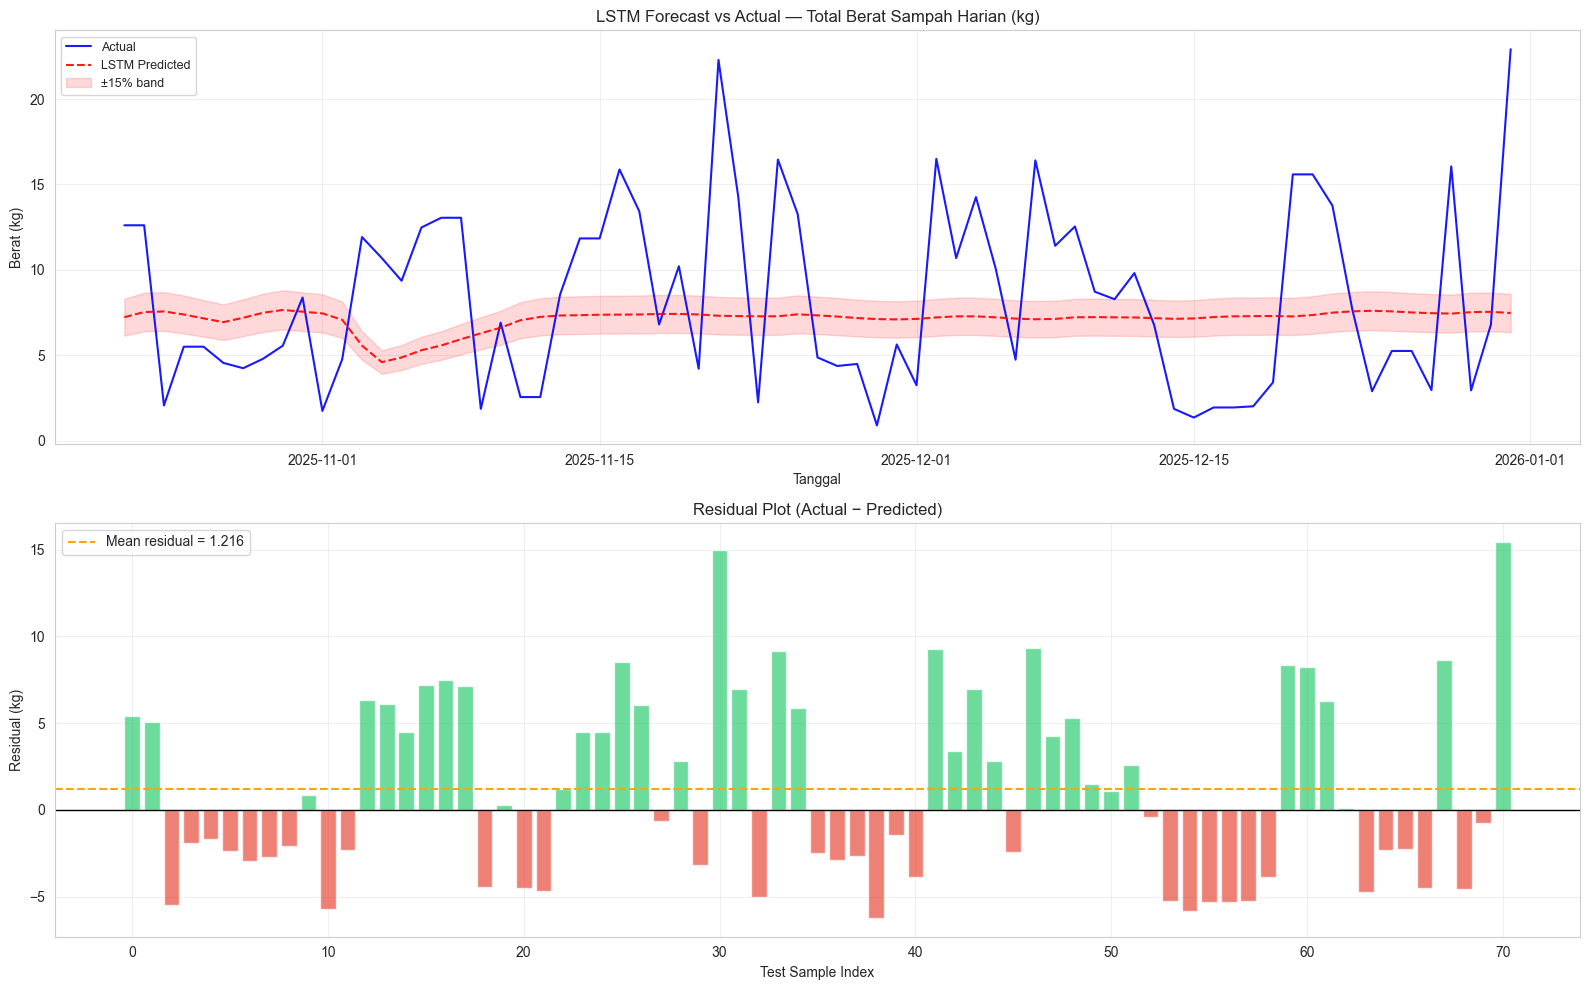


Generating 30-day rolling forecast...

Forecast Berat Sampah 30 Hari ke Depan:
  2026-01-01 → 7.42 kg
  2026-01-02 → 7.26 kg
  2026-01-03 → 7.11 kg
  2026-01-04 → 6.94 kg
  2026-01-05 → 6.75 kg
  2026-01-06 → 6.67 kg
  2026-01-07 → 6.60 kg
  2026-01-08 → 6.52 kg
  2026-01-09 → 6.43 kg
  2026-01-10 → 6.32 kg
  2026-01-11 → 6.11 kg
  2026-01-12 → 5.83 kg
  2026-01-13 → 5.80 kg
  2026-01-14 → 5.73 kg
  2026-01-15 → 5.66 kg
  2026-01-16 → 5.65 kg
  2026-01-17 → 5.64 kg
  2026-01-18 → 5.63 kg
  2026-01-19 → 5.62 kg
  2026-01-20 → 5.62 kg
  2026-01-21 → 5.61 kg
  2026-01-22 → 5.60 kg
  2026-01-23 → 5.60 kg
  2026-01-24 → 5.59 kg
  2026-01-25 → 5.59 kg
  2026-01-26 → 5.59 kg
  2026-01-27 → 5.59 kg
  2026-01-28 → 5.59 kg
  2026-01-29 → 5.59 kg
  2026-01-30 → 5.59 kg

✅ LSTM selesai.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── 1. Prediksi pada test set ─────────────────────────────────────────────────
y_pred_scaled = model_lstm.predict(X_test)

# Inverse transform
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled).flatten()
y_test_actual = target_scaler.inverse_transform(y_test).flatten()

# ── 2. Metrik evaluasi ────────────────────────────────────────────────────────
mae_lstm  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape_lstm = np.mean(np.abs((y_test_actual - y_pred_actual) / (y_test_actual + 1e-9))) * 100

print("=" * 55)
print("EVALUASI LSTM")
print("=" * 55)
print(f"MAE  : {mae_lstm:.3f} kg")
print(f"RMSE : {rmse_lstm:.3f} kg")
print(f"MAPE : {mape_lstm:.2f} %")

# Perbandingan dengan Prophet
print("\n--- Perbandingan Prophet vs LSTM ---")
print(f"{'Model':<10} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print(f"{'Prophet':<10} {mae:>8.3f} {rmse:>8.3f} {mape:>7.2f}%")
print(f"{'LSTM':<10} {mae_lstm:>8.3f} {rmse_lstm:>8.3f} {mape_lstm:>7.2f}%")

# ── 3. Visualisasi prediksi LSTM ─────────────────────────────────────────────
test_dates = lstm_daily['date'].iloc[split + LOOKBACK : split + LOOKBACK + len(y_test_actual)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Panel A: Actual vs Predicted
axes[0].plot(test_dates, y_test_actual, 'b-', linewidth=1.5, label='Actual', alpha=0.9)
axes[0].plot(test_dates, y_pred_actual, 'r--', linewidth=1.5, label='LSTM Predicted', alpha=0.9)
axes[0].fill_between(test_dates,
                     y_pred_actual * 0.85, y_pred_actual * 1.15,
                     alpha=0.15, color='red', label='±15% band')
axes[0].set_title('LSTM Forecast vs Actual — Total Berat Sampah Harian (kg)', fontweight='bold')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Berat (kg)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel B: Residual plot
residuals = y_test_actual - y_pred_actual
axes[1].bar(range(len(residuals)), residuals,
            color=['#E74C3C' if r < 0 else '#2ECC71' for r in residuals],
            alpha=0.7, width=0.8)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axhline(residuals.mean(), color='orange', linestyle='--',
                label=f'Mean residual = {residuals.mean():.3f}')
axes[1].set_title('Residual Plot (Actual − Predicted)', fontweight='bold')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('Residual (kg)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/lstm_evaluation.png", dpi=120, bbox_inches='tight')
plt.show()

# ── 4. Forecast 30 hari ke depan (rolling) ────────────────────────────────────
print("\nGenerating 30-day rolling forecast...")

last_sequence = lstm_scaled[-LOOKBACK:].copy()
future_preds = []

for day in range(30):
    input_seq = last_sequence[-LOOKBACK:].reshape(1, LOOKBACK, len(LSTM_FEATURES))
    pred = model_lstm.predict(input_seq, verbose=0)[0, 0]
    future_preds.append(pred)

    # Buat row baru: geser window, gunakan pred sebagai feature 'weight'
    next_day = last_sequence[-1].copy()
    next_day[0] = pred   # index 0 = weight (feature pertama)
    last_sequence = np.vstack([last_sequence[1:], next_day])

future_preds_actual = target_scaler.inverse_transform(
    np.array(future_preds).reshape(-1, 1)).flatten()

last_date = lstm_daily['date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=30, freq='D')

print("\nForecast Berat Sampah 30 Hari ke Depan:")
for d, p in zip(future_dates, future_preds_actual):
    print(f"  {d.date()} → {p:.2f} kg")

print(f"\n✅ LSTM selesai.")

# **32. Dashboard Plotly Interaktif**

In [ ]:
!pip install plotly -q

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Dashboard 1: Overview + Peak Time ────────────────────────────────────────
fig1 = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Peak Disposal Hour (Count)',
        'Weekday vs Weekend per Jam',
        'Heatmap Berat: Jam × Hari',
        'Distribusi Jenis Sampah'
    ),
    specs=[[{"type":"bar"},{"type":"bar"}],
           [{"type":"heatmap"},{"type":"bar"}]]
)

# Panel A: Peak hour count
colors_ph = ['#E74C3C' if h in PEAK_HOURS_IDENTIFIED else '#3498DB'
             for h in hourly['hour']]
fig1.add_trace(go.Bar(x=hourly['hour'], y=hourly['count'],
                      marker_color=colors_ph, name='Count/Jam',
                      text=hourly['count'], textposition='outside'), row=1, col=1)

# Panel B: Weekday vs Weekend
wk_p = df[~df['is_weekend']].groupby('hour')['record_id'].count()
we_p = df[df['is_weekend']].groupby('hour')['record_id'].count()
fig1.add_trace(go.Bar(x=wk_p.index, y=wk_p.values, name='Weekday',
                      marker_color='#2ECC71', opacity=0.8), row=1, col=2)
fig1.add_trace(go.Bar(x=we_p.index, y=we_p.values, name='Weekend',
                      marker_color='#9B59B6', opacity=0.8), row=1, col=2)

# Panel C: Heatmap jam × hari
pivot_hd2 = df.groupby(['hour','day_name'])['weight_kg'].sum().unstack(fill_value=0)
pivot_hd2 = pivot_hd2.reindex(columns=[d for d in day_order if d in pivot_hd2.columns])
fig1.add_trace(go.Heatmap(z=pivot_hd2.values, x=pivot_hd2.columns.tolist(),
                           y=pivot_hd2.index.tolist(), colorscale='YlOrRd',
                           showscale=True, name='Weight Heatmap'), row=2, col=1)

# Panel D: Label distribution
all_labels2 = df['detected_labels'].str.split('|').explode()
lc2 = all_labels2.value_counts()
fig1.add_trace(go.Bar(x=lc2.index, y=lc2.values,
                      marker_color=['#E74C3C','#3498DB','#2ECC71','#F39C12'],
                      name='Label Count'), row=2, col=2)

fig1.update_layout(
    title_text='🗑️ Dashboard 1: Peak Disposal Time & Overview',
    title_font_size=16,
    height=750, showlegend=True,
    template='plotly_white'
)
fig1.update_layout(barmode='group')
fig1.write_html(f"{PROJECT_DIR}/dashboard_peak_overview.html")
fig1.show()
print("✅ Dashboard 1 disimpan ke dashboard_peak_overview.html")

# ── Dashboard 2: Clustering ───────────────────────────────────────────────────
fig2 = make_subplots(
    rows=1, cols=2,
    subplot_titles=('K-Means Clusters (PCA)', 'DBSCAN Clusters (PCA)'),
    specs=[[{"type":"scatter"},{"type":"scatter"}]]
)

palette_plotly = px.colors.qualitative.Set2
for c in sorted(user_stats['kmeans_cluster'].unique()):
    mask = user_stats['kmeans_cluster'] == c
    lab  = user_stats.loc[mask, 'kmeans_label'].iloc[0]
    fig2.add_trace(go.Scatter(
        x=user_stats.loc[mask,'pca_x'], y=user_stats.loc[mask,'pca_y'],
        mode='markers', name=lab, marker=dict(size=8, color=palette_plotly[c % 8]),
        text=user_stats.loc[mask,'user_id'], hoverinfo='text+name'), row=1, col=1)

db_labels2 = user_stats['dbscan_cluster']
for lbl in sorted(db_labels2.unique()):
    mask = db_labels2 == lbl
    col  = 'lightgray' if lbl == -1 else palette_plotly[lbl % 8]
    name = 'Noise' if lbl == -1 else f'DB-Cluster {lbl}'
    fig2.add_trace(go.Scatter(
        x=user_stats.loc[mask,'pca_x'], y=user_stats.loc[mask,'pca_y'],
        mode='markers', name=name,
        marker=dict(size=8, color=col, symbol='x' if lbl == -1 else 'circle'),
        text=user_stats.loc[mask,'user_id'], hoverinfo='text+name'), row=1, col=2)

fig2.update_layout(
    title_text='🔵 Dashboard 2: Clustering Result (K-Means & DBSCAN)',
    title_font_size=16, height=550, template='plotly_white'
)
fig2.write_html(f"{PROJECT_DIR}/dashboard_clustering.html")
fig2.show()
print("✅ Dashboard 2 disimpan ke dashboard_clustering.html")

# ── Dashboard 3: Forecasting ──────────────────────────────────────────────────
fig3 = make_subplots(rows=2, cols=1,
    subplot_titles=('Prophet Forecast — Berat Harian (kg)',
                    'LSTM Forecast — Test Set Actual vs Predicted'),
    shared_xaxes=False)

# Prophet
fig3.add_trace(go.Scatter(x=train_ts['ds'], y=train_ts['y'], mode='lines',
                           name='Train Actual', line=dict(color='royalblue', width=1)), row=1, col=1)
fig3.add_trace(go.Scatter(x=test_ts['ds'], y=test_ts['y'], mode='lines',
                           name='Test Actual', line=dict(color='green', width=1.5)), row=1, col=1)
fig3.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat'], mode='lines',
                           name='Prophet Forecast', line=dict(color='red', dash='dash', width=1.5)), row=1, col=1)
fig3.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(255,0,0,0.08)',
    line=dict(color='rgba(255,255,255,0)'), name='95% CI'), row=1, col=1)

# LSTM
fig3.add_trace(go.Scatter(x=list(range(len(y_test_actual))), y=y_test_actual,
                           mode='lines', name='LSTM Actual',
                           line=dict(color='royalblue', width=1.5)), row=2, col=1)
fig3.add_trace(go.Scatter(x=list(range(len(y_pred_actual))), y=y_pred_actual,
                           mode='lines', name='LSTM Predicted',
                           line=dict(color='red', dash='dash', width=1.5)), row=2, col=1)

fig3.update_layout(
    title_text='📈 Dashboard 3: Forecasting — Prophet & LSTM',
    title_font_size=16, height=800, template='plotly_white'
)
fig3.write_html(f"{PROJECT_DIR}/dashboard_forecasting.html")
fig3.show()
print("✅ Dashboard 3 disimpan ke dashboard_forecasting.html")

✅ Dashboard 1 disimpan ke dashboard_peak_overview.html


✅ Dashboard 2 disimpan ke dashboard_clustering.html


✅ Dashboard 3 disimpan ke dashboard_forecasting.html


# **33. Ringkasan Akhir & Export Semua Hasil**

In [ ]:
print("=" * 65)
print("   WASTE DISPOSAL TIME PATTERN RECOGNITION — FINAL SUMMARY")
print("=" * 65)

print("""
📦 DATASET
  • Total records    : {:,}
  • Rentang waktu    : {} → {}
  • Kecamatan        : {:,} area
  • Total berat      : {:.2f} kg
""".format(
    len(df),
    df['timestamp'].min().date(), df['timestamp'].max().date(),
    df['kecamatan'].nunique(),
    df['weight_kg'].sum()
))

print("""
🎯 YOLOV8 — Object Detection
  • Classes          : biodegradable, recyclable, residual, special
  • Best mAP50       : 0.644
  • Best mAP50-95    : 0.488
  • Precision        : 0.753
  • Recall           : 0.546
""")

peak_str = ', '.join([f'{h:02d}:00' for h in sorted(PEAK_HOURS_IDENTIFIED)])
print(f"""
⏰ PEAK DISPOSAL TIME
  • Peak hours       : {peak_str}
  • Peak hour ratio  : {df['is_peak_hour'].mean()*100:.1f}% records
  • Hari terberat    : {df.groupby('day_name')['weight_kg'].sum().idxmax()}
""")

print(f"""
🔵 CLUSTERING
  • K-Means K        : {K_OPTIMAL} clusters
  • K-Means Sil.     : {silhouette_score(X_scaled, user_stats['kmeans_cluster']):.4f}
  • DBSCAN clusters  : {n_clusters_db}
  • DBSCAN noise     : {n_noise} users ({n_noise/len(user_stats)*100:.1f}%)
""")

print(f"""
📈 FORECASTING
  ┌──────────┬───────────┬───────────┬────────────┐
  │ Model    │    MAE    │    RMSE   │    MAPE    │
  ├──────────┼───────────┼───────────┼────────────┤
  │ Prophet  │ {mae:>9.3f} │ {rmse:>9.3f} │ {mape:>8.2f}%  │
  │ LSTM     │ {mae_lstm:>9.3f} │ {rmse_lstm:>9.3f} │ {mape_lstm:>8.2f}%  │
  └──────────┴───────────┴───────────┴────────────┘
""")

# Simpan dataset final dengan kolom clustering
OUTPUT_FINAL = f"{CSV_DIR}/dataset_final_with_clusters.csv"
df.to_csv(OUTPUT_FINAL, index=False)
print(f"✅ Dataset final (dengan cluster labels) disimpan ke:")
print(f"   {OUTPUT_FINAL}")

print("""
✅ FILE OUTPUT SUMMARY
  • dataset_final_with_clusters.csv
  • analysis_peak_disposal_time.png
  • analysis_behavior_pattern.png
  • kmeans_elbow_silhouette.png
  • kmeans_clustering_result.png
  • dbscan_kdistance.png
  • dbscan_clustering_result.png
  • timeseries_daily.png
  • prophet_forecast.png
  • prophet_components.png
  • lstm_training_history.png
  • lstm_evaluation.png
  • lstm_best_model.keras
  • dashboard_peak_overview.html
  • dashboard_clustering.html
  • dashboard_forecasting.html
""")

print("🎉 PROYEK SELESAI — Siap presentasi!")

   WASTE DISPOSAL TIME PATTERN RECOGNITION — FINAL SUMMARY

📦 DATASET
  • Total records    : 1,010
  • Rentang waktu    : 2025-01-01 → 2025-12-31
  • Kecamatan        : 12 area
  • Total berat      : 2702.24 kg


🎯 YOLOV8 — Object Detection
  • Classes          : biodegradable, recyclable, residual, special
  • Best mAP50       : 0.644
  • Best mAP50-95    : 0.488
  • Precision        : 0.753
  • Recall           : 0.546


⏰ PEAK DISPOSAL TIME
  • Peak hours       : 12:00, 13:00, 18:00, 19:00
  • Peak hour ratio  : 67.7% records
  • Hari terberat    : Senin


🔵 CLUSTERING
  • K-Means K        : 2 clusters
  • K-Means Sil.     : 0.1632
  • DBSCAN clusters  : 1
  • DBSCAN noise     : 0 users (0.0%)


📈 FORECASTING
  ┌──────────┬───────────┬───────────┬────────────┐
  │ Model    │    MAE    │    RMSE   │    MAPE    │
  ├──────────┼───────────┼───────────┼────────────┤
  │ Prophet  │     5.245 │     6.910 │ 39155428760.35%  │
  │ LSTM     │     4.655 │     5.524 │    93.08%  │
  └─────────